# DEFINING THE BUSINESS PROBLEM

## Introduction

Greetings, we are team CardioIntellect.

### Dataset

We will be using the class-provided dataset, "Heart Disease" from UCI Machine Learning, which is found at this [link](https://archive.ics.uci.edu/dataset/45/heart+disease).

## Question Definition

**Can a machine learning model be designed that can accurately predict the presence of heart disease? Should this model be implemented to assist doctor evaluations?**

>It is argued that while automatic methods can be useful, the best way is to perform a manual feature selection by using problem domain knowledge, i.e., by having a clear understanding of what the attributes mean. Moro, Cortez, Rita, 2014, pg. 12
  
In this project, we propose that either a DT or a LR model will prove sufficient in answering the defined question(s) and that via methods such as evaluative feature selection and hyperparameter tuning, overfitting can be minimized. In this way, prediction of heart disease can be linked to predictive factors.

## Problem Definition

**Predicting the existence of heart disease.**  
In this project, we will focus on comparing a Logistic Regression (LR) model to a Decision Tree (DT) model.

## Business Relevance

The business relevance of creating predictive models, such as that defined within this project, carries implications of improved success diagnosing heart disease. In this case study, the refined understanding of the comparison between models could save lives.

## Imports

The first code block handles all the imports that are used in this project.  

In [2]:
# installs, run once
!pip3 install -U ucimlrepo


# imports, run on kernal refresh
# data & processing
from ucimlrepo import(
    fetch_ucirepo, list_available_datasets
)
import warnings
import pandas as pd
import os
import random
import seaborn as sns
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from numpy import(
    sqrt,
    argmax,
)
from pprint import pprint

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.utils import shuffle
from sklearn.tree import export_graphviz
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import(
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import(
    make_scorer,
    accuracy_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    auc,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import(
    LabelBinarizer,
    StandardScaler
)

## Section 1 Closing Comments/# Notes

Throughout the project, we have commented (#) separated units of code blocks and noted functionality. Notes to the side or following '#' indicate the functionality of individual lines. Occasionally, there may be commented-out alternative methods of achieving unit code function or referential code that was used in the early stages of this project's development.

# DESCRIBE THE DATASET

## Context

The dataset we've been provided originally consisted of four databases containing patient data from Cleveland, Ohio, the VA (Veterans' Affairs) Long Beach Healthcare System, Switzerland, and Hungary. The data is from 1988, with the portion that we've analysed being a processed version of the Cleveland database. Of the 76 attributes that were collected, the processed version was culled down to 14, such as age, cholesterol, and resting blood pressure.

## Python Describing the Dataset

The next code blocks and output describe the dataset using Python functions and include the **Data Dictionary**:

In [4]:
# dataset dataframe generated from csv
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

# turn into data frame
heart_disease_features = pd.DataFrame (X)
heart_disease_targets = pd.DataFrame (y)
df = pd.concat([heart_disease_features, heart_disease_targets], axis=1)

# access variable info in tabular format
print ('************')
print('Data dictionary and additional variable info: ')
print(heart_disease.variables)

print ('************')
print('Additional info: ')
print(heart_disease.metadata.additional_info.summary)

# minimal preprocessing
df['num'] = df['num'].apply(lambda x: 1 if x >= 1 else 0)

# alternatively use LabelBinarizer
#lb = LabelBinarizer()
#df['num'] = lb.fit_transform(df['num'])

************
Data dictionary and additional variable info: 
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                

## Data Dictionary

1. **age** = **(integer)** age in years (integer, median age: 56, range: 29 - 77 years, standard deviation: 9.03)
2. **sex** = **(categorical)** 1 = male (count : 206) , 0 = female (count : 97)
3. **cp** = **(categorical)** (cp = chest pain type) Value 1: typical angina (count: 23), Value 2: atypical angina (count: 50), Value 3: non-anginal pain    (count: 86), Value 4: asymptomatic(count: 144)
4. **trestbps** = **(integer)** resting blood pressure measured in millimeters of mercury (mmHg). Values < 120/80 mmHg are considered normal, whilst higher values indicate hypertension, a contributor to the development of heart disease.  (integer , median : 130.0 , range : 94 - 200  ,  standard deviation : 17.59)
5. **chol** = **(integer)** (in milligrams per deciliter) serum cholesterol in milligrams per deciliter (mg/dl). Higher values correlate with heart disease. (integer , median : 241 , range : 126 - 564 , standard deviation : 51.77)
6. **fbs** = **(categorical)** fasting blood sugar > 120mg/dl 1 = true (count: 45) , 0 = false (count: 258). True figures indicate diabetes/prediabetes, which contribute to heart disease. 
7. **restecg** = **(categorical)** (resting electrocardiographic results) Value 0: normal, Value (count: 151) 1: having ST-T wave abnormality(T wave inversions and/or ST elevation or depression of > 0.05 mV, count: 4) Value 2: showing probable or definite left ventricular hypertrophyby Estes' criteria, count: 148)
8. **thalach** = **(integer)** peak heart rate after exercise. Lower values generally indicate stronger cardiovascular health and efficiency. Normal range decreases with age. (integer , median: 153 , range : 71 -202 , standard deviation : 27.87)
9. **exang** = **(categorical)** (exercise induced angina) exercise induced angina(reduced oxygen rich blood flow to heart, chest pain or discomfort) 1= yes (count : 99) , 0 = no (count : 204)
10. **oldpeak** = **(integer)** ST depression induced by exercise relative to rest (median: 0.8, range : 0 - 6.2, standard deviation: 1.16)
11. **slope** = **(categorical)** the slope of the peak exercise ST segment Value 1: upsloping (norm, count: 142), Value 2: flat (bad   can indicate a lack of blood flow (ischemia), count: 140 ), Value 3: downsloping (very bad, count: 2)
12. **ca** = **(integer)** number of major vessels (0-3) colored by fluoroscopy. Having more colored vessels is associated with increasing severity of heart disease.  Missing 4 data points. ( median : 0 , range : 0 - 3 , standard deviation : 0.93)
13. **thal** = **(categorical)** thal: 3 = normal (healthy, count: 166); 6 = fixed defect (signs of previous heart attack or heart damage, count: 18), 7 = reversible defect (induced ischemia: not enough oxygen during stress)(count: 117). Missing 2 data points.
14. **num** = **(target)** 1 = presence of heart disease 0 = absent (count: 134, 1-4 present (converted numbers >=1 to 1: count: 164, range 0-1, standard deviation: 0.49

## Data Exploration

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
# rows (individuals in the study) and columns (attributes) of the dataset (rows, columns)
df.shape

(303, 14)

In [8]:
# printing column names
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [9]:
# Check for duplicates
dp_val = df.duplicated().any()
print(dp_val)

False


In [10]:
# assessing data types and checking for null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


### A note on NaN data

Being that CA is a feature of importance, we're dropping NaN data which accounts for 6 rows or less than 2% of the data.

In [12]:
# printing number of rows with heart disease (num > 0)
count_positive = (df['num'] > 0).sum()
print(f"Number of rows with heart disease (num > 0): {count_positive}")
count_positive = (df['num'] < 1).sum()
print(f"Number of rows without heart disease (num < 1): {count_positive}")

Number of rows with heart disease (num > 0): 139
Number of rows without heart disease (num < 1): 164


In [13]:
# printing column names for categorical fields
categorical = heart_disease.variables.query("type == 'Categorical'")['name'].tolist()

print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are:', categorical)


There are 7 categorical variables

The categorical variables are: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [14]:
# printing count of categorical labels for each field assessed as categorical
for var in categorical:
    print(var, ' contains ', len(df[var].unique()), ' labels')

sex  contains  2  labels
cp  contains  4  labels
fbs  contains  2  labels
restecg  contains  3  labels
exang  contains  2  labels
slope  contains  3  labels
thal  contains  4  labels


### Class Distribution and Kurtosis

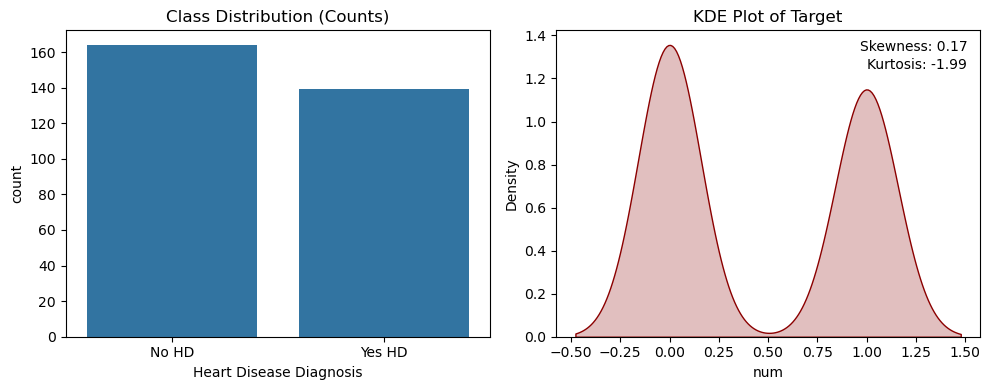

In [16]:
# Class distribution and kurtosis
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Countplot of target variable
sns.countplot(data=df, x="num", ax=axes[0])
axes[0].set_title("Class Distribution (Counts)")
axes[0].set_xlabel("Heart Disease Diagnosis")
tick_locs = axes[0].get_xticks()
axes[0].set_xticks(tick_locs)
axes[0].set_xticklabels(['No HD', 'Yes HD'])

# Plot 2: KDE + skew/kurtosis annotations
sns.kdeplot(data=df, x="num", fill=True, ax=axes[1], color='darkred')
axes[1].set_title("KDE Plot of Target")

# Annotate skewness and kurtosis
axes[1].text(0.97, 0.97, f"Skewness: {df['num'].skew():.2f}",
             transform=axes[1].transAxes, ha='right', va='top', fontsize=10)
axes[1].text(0.97, 0.91, f"Kurtosis: {df['num'].kurt():.2f}",
             transform=axes[1].transAxes, ha='right', va='top', fontsize=10)

plt.tight_layout()
plt.show()

**Skewness**  
A measure of asymmetry in the distribution.  
Values:

- 0: Perfectly symmetrical
- \> 0: Right-skewed (longer tail on the right)
- < 0: Left-skewed

**Kurtosis**  
A measure of "tailedness" or how extreme the outliers are.  
Compared to a normal distribution (kurtosis = 0 after Fisher adjustment):

- \> 0: Heavy tails, possible outliers
- < 0: Light tails, data clustered tightly

### Histograms

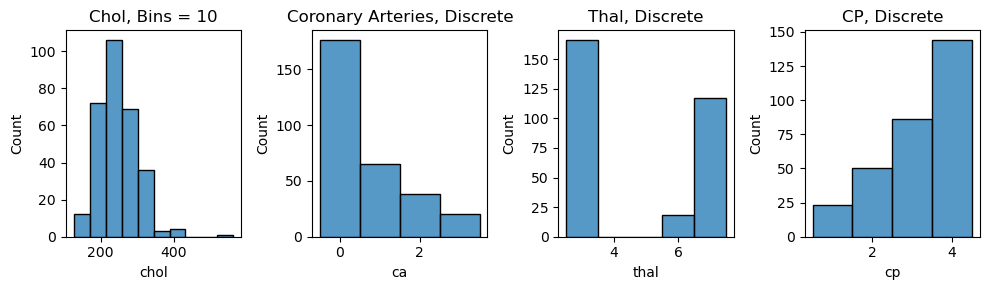

In [19]:
# Histograms to confirm these assessments
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

# Plot each graph on a separate axis
sns.histplot(data=df, x='chol', bins=10, ax=axes[0])
axes[0].set_title("Chol, Bins = 10")

sns.histplot(data=df, x='ca', discrete=True, ax=axes[1])
axes[1].set_title("Coronary Arteries, Discrete")

sns.histplot(data=df, x='thal', discrete=True, ax=axes[2])
axes[2].set_title("Thal, Discrete")

sns.histplot(data=df, x='cp', discrete=True, ax=axes[3])
axes[3].set_title("CP, Discrete")

plt.tight_layout()
plt.show()

### Boxplots

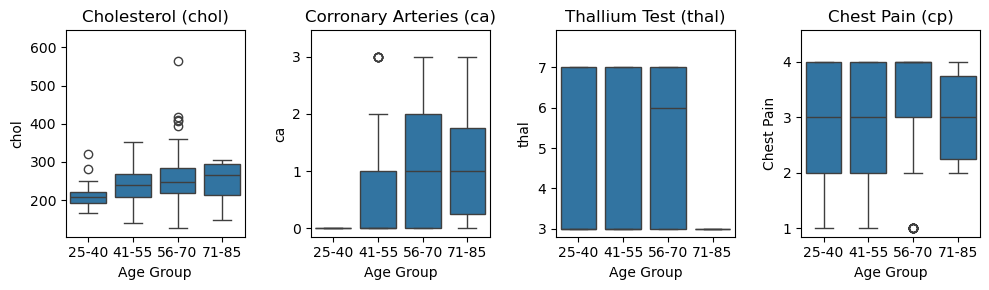

In [21]:
# Define age buckets
df['age_group'] = pd.cut(
    df['age'],
    bins=[25, 40, 55, 70, 85],
    labels=['25-40', '41-55', '56-70', '71-85']
)

# Set up figure with 4 horizontal boxplots
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

sns.boxplot(data=df, x='age_group', y='chol', ax=axes[0])
axes[0].set_title('Cholesterol (chol)')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('chol')
ymin, ymax = axes[0].get_ylim()
axes[0].set_ylim(ymin, ymax * 1.1)

sns.boxplot(data=df, x='age_group', y='ca', ax=axes[1])
axes[1].set_title('Corronary Arteries (ca)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('ca')
ymin, ymax = axes[1].get_ylim()
axes[1].set_ylim(ymin, ymax * 1.1)

sns.boxplot(data=df, x='age_group', y='thal', ax=axes[2])
axes[2].set_title('Thallium Test (thal)')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('thal')
ymin, ymax = axes[2].get_ylim()
axes[2].set_ylim(ymin, ymax * 1.1)

sns.boxplot(data=df, x='age_group', y='cp', ax=axes[3])
axes[3].set_title('Chest Pain (cp)')
axes[3].set_xlabel('Age Group')
axes[3].set_ylabel('Chest Pain')
ymin, ymax = axes[3].get_ylim()
axes[3].set_ylim(ymin, ymax * 1.1)

plt.tight_layout()
plt.show()

### Heatmap/Corr Matrix

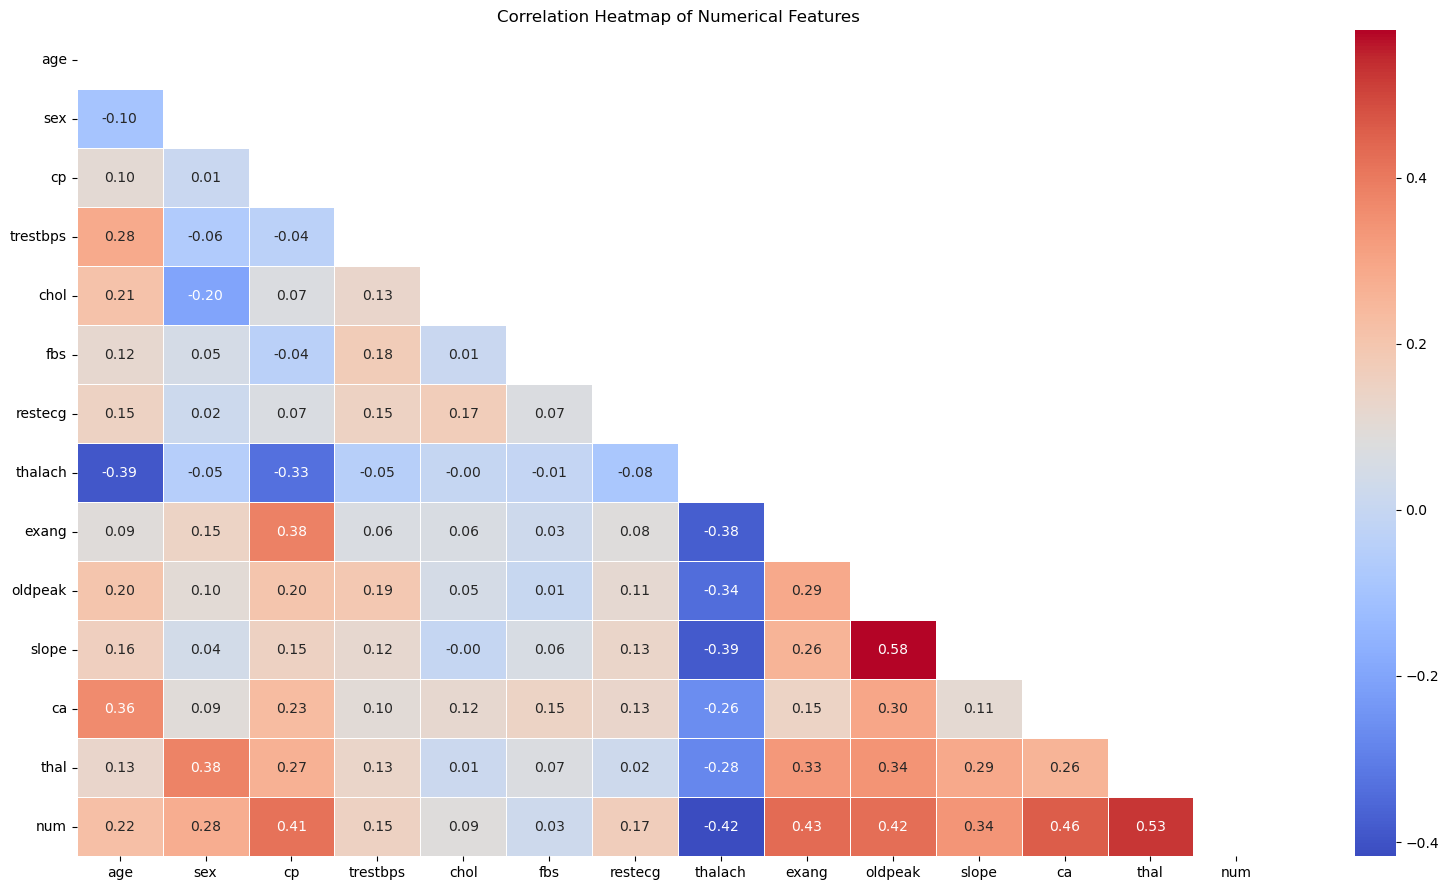

In [23]:
# Filter to only numeric columns before computing correlation
numeric_df = df.select_dtypes(include='number')

# Compute correlation matrix
corr = numeric_df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
plt.figure(figsize=(16, 9))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

This heatmap visualizes pairwise linear correlations between all numeric features in the dataset. The following steps were taken:

- Non-numeric columns were excluded to avoid computation errors.
- Pearson correlation coefficients were calculated — values range from -1 (perfect negative) to +1 (perfect positive) correlation.
- A mask hides the upper triangle to eliminate redundant information (correlation matrices are symmetric).
- The heatmap uses a 'coolwarm' colormap, making strong positive correlations red, negative ones blue, and near-zero correlations white.

Use this plot to:

- Spot strong feature relationships (e.g., collinearity).
- Identify redundant or highly related variables that may affect model performance or interpretability.

In this case, the most important correlations are between the target (num) and each feature.

### Minimal Pre-processing

In [26]:
# Pre-processing
# Drop rows with NaNs in X, and align y accordingly
X = X.dropna()
y = y.loc[X.index]

# Convert y to 0 (no disease) or 1 (disease)
y = (y != 0).astype(int).values.ravel() # Convert y to binary 1D array

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
297   57    0   4       140   241    0        0      123      1      0.2   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1        2  3.0   3.0  
2        2  2.0

**This code prepares the data for modeling by:**

- Removing rows with missing values in X and aligning y accordingly.
- Converting the target variable y to a binary format: 1 for disease, 0 for no disease.
- Splitting the dataset into training and test sets using stratified sampling to preserve class balance.

### A note on Logistic Regression standardization

**Logistic Regression is a linear model, and the scale of the feature influences the size of the coefficient (β):**

- A feature in the range [0, 1] might have a large coefficient.
- A feature in the range [0, 10,000] might have a small coefficient — even if it’s just as important.

Without standardization, comparing coefficient sizes across features becomes misleading — it reflects both effect and scale.  
With standardization, features are on an equal footing, so the coefficients now reflect pure influence on the prediction.

**StandardScaler transforms each feature by removing the mean and scaling to unit variance:**

- $x_{scaled} = \frac{x - \mu}{\sigma}$

Where:

- μ is the mean of the feature
- σ is the standard deviation of the feature

After standardization:

- Each feature will have a mean of 0
- Each feature will have a standard deviation of 1

## Training Models

### LR (Training)

In [28]:
# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit the model
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
logreg.fit(X_train_scaled_df, y_train)

# Use X_test_scaled_df for predictions
y_pred_lr = logreg.predict(X_test_scaled_df)
yhat_glr = logreg.predict_proba(X_test_scaled_df)[:, 1]

# Precision-recall data
p_glr, r_glr, t_glr = precision_recall_curve(y_test, yhat_glr)

# Get feature importances from logistic regression
feature_importances_lr = pd.Series(abs(logreg.coef_[0]), index=X.columns).sort_values(ascending=False)

# Calculate the AUC value
auc = roc_auc_score(y_test, yhat_glr)
print('AUC Value: ')
print(round(auc,2))

AUC Value: 
0.95


**This code builds and evaluates a logistic regression model by:**

- Initializing the model with a fixed solver and random seed.  
- Standardizing the training and test features to have a mean of 0 and a standard deviation of 1.  
- Fitting the model on the scaled training data.  
- Generating predictions and prediction probabilities on the test set.  
- Calculating feature importances using the absolute values of the model’s coefficients.

**Interpretation:**

- There’s a 95% chance the model will assign a higher probability to a randomly chosen positive case (y=1) than to a randomly chosen negative case (y=0).

### RFC (Training)

In [31]:
# instantiate the model
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

# fit the model
rfc.fit(X_train, y_train)

# Predictions
y_pred_grfc = rfc.predict(X_test)
yhat_grfc = rfc.predict_proba(X_test)[:, 1]

# Precision-recall data
p_grfc, r_grfc, t_grfc = precision_recall_curve(y_test, yhat_grfc)

# Get feature importances from random classifier
feature_importances_rfc = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)

auc = roc_auc_score(y_test, yhat_grfc)
print('AUC Value:')
print(round(auc, 2))

AUC Value:
0.94


**This code builds and evaluates a random forest classifier by:**

- Initializing the model with a fixed random seed and parallel processing enabled.
- Training it on the unscaled training data.
- Generating class predictions and prediction probabilities on the test set.
- Computing precision-recall values for evaluation.
- Extracting feature importances based on how much each feature contributes to reducing impurity in the trees.

**Interpretation:**

- There’s a 94% chance the model will assign a higher probability to a randomly chosen positive case (y=1) than to a randomly chosen negative case (y=0).

## Feature Importances (SciKitLearn)

In [34]:
# feature importance function with side by side display
def plot_feature_importances(fi1, fi2, label1='Model 1', label2='Model 2', top_n=5):
    # Normalize to [0,1]
    fi1 = (fi1 - fi1.min()) / (fi1.max() - fi1.min())
    fi2 = (fi2 - fi2.min()) / (fi2.max() - fi2.min())

    # Sort and trim to top N
    fi1 = fi1.sort_values(ascending=False).head(top_n)
    fi2 = fi2.sort_values(ascending=False).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

    fi1.plot.bar(ax=axes[0])
    axes[0].set_title(f'Top {top_n} Normalized Importances - {label1}')
    axes[0].set_ylabel("Normalized Importance")

    fi2.plot.bar(ax=axes[1])
    axes[1].set_title(f'Top {top_n} Normalized Importances - {label2}')

    plt.tight_layout()
    plt.show()

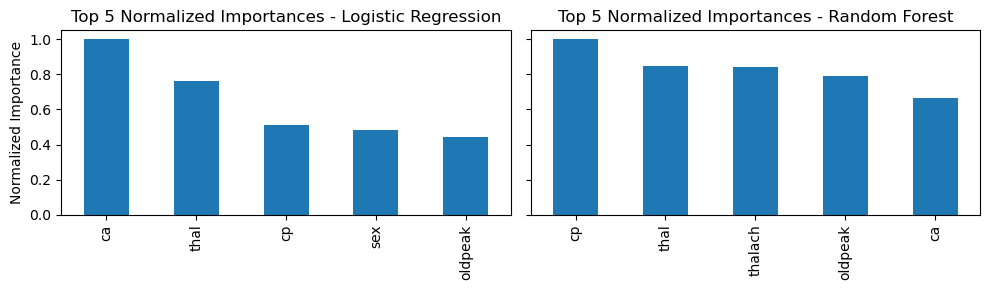

In [35]:
# call of feature importance function
plot_feature_importances(
    feature_importances_lr,
    feature_importances_rfc,
    label1='Logistic Regression',
    label2='Random Forest'
)

**Feature Importance**  
Logistic Regression emphasizes scaled linear contributions, while Random Forest captures non-linear feature interactions. The difference in top features may reflect this distinction.

## Section 2 Comments/# Notes

The code blocks above describe the dataset and the transition through preprocessing for generic model applications. We can see that features ca, thal, cp, oldpeak, sex, and thalach have the highest feature importance across these two models. This observation will be expanded on in Appendix A.

# DEFINING THE OUTCOMES

## Outcome Variable

The outcome variable represents whether a patient has heart disease, defined by the num attribute in the dataset. For modeling purposes, this has been converted to a binary classification problem:

- 1 indicates presence of heart disease ("yes")
- 0 indicates no heart disease ("no")

This binary format (often referred to as variable y) allows the model to predict the presence or absence of disease.

## Defining the Link to the Problem and Question

Given that y is a binary classification variable, the problem is well-suited to supervised classification models. However, while accuracy might appear to be a sufficient metric, it can be misleading — especially when class imbalance is present.

As noted by Roy (2019):

>If we use accuracy as our metric, any random model can give us a very good accuracy. But at the end, it will be a random model. AUC gets over this problem by looking into both the True Positive Rate (TPR) and False Positive Rate (FPR). Only if both the TPR and FPR are well above the random line in the ROC curve, will we get a good AUC. Accuracy does not guarantee that.

Thus, when evaluating the outcome variable, metric selection becomes critical. AUC is favored in this context, as it captures the balance between sensitivity (TPR) and specificity (TNR). This is particularly important given that class imbalance in the dataset increases the likelihood of models producing false negatives, which is clinically problematic.

Confusion matrices also provide valuable insight into model behavior, despite some limitations when class imbalance is severe.

## Considered Metrics

- True Positive (TP): Correctly predicted positive cases
- True Negative (TN): Correctly predicted negative cases
- False Positive (FP): Incorrectly predicted positive cases
- False Negative (FN): Missed positive cases

Key derived metrics:

- True Positive Rate | Sensitivity | Recall: TPR = TP / (TP + FN)
- True Negative Rate | Specificity: TNR = TN / (TN + FP)
- Precision | Positive Predictive Value: PPV = TP / (TP + FP)
- Negative Predictive Value: NPV = TN / (TN + FN)
- False Positive Rate: FPR = FP / (FP + TN)
- False Negative Rate: FNR = FN / (TP + FN)
- False Discovery Rate: FDR = FP / (TP + FP)
- Overall Accuracy: ACC = (TP + TN) / (TP + FP + FN + TN)

# DEFINING THE METHOD(S)

## Model Method

We will be comparing a Logistic Regression (LR) model to that of a Random Forest Classifier (RFC) model. These models are implemented using scikit-learn and are designed to predict the presence of heart disease using the provided dataset as training. Primary results will be compared on a confusion matrix basis for the locked 20% test sample. Receiver Operating Characteristic (ROC) and Precision-Recall Curves are then scrutinized for threshold adjustment

### Logistic Regression vs. Random Forest

As noted in Random Forest vs Logistic Regression: Binary Classification for Heterogeneous Datasets (Kirasich, Smith, Bivin, 2018):

>Random Forest is an ensemble-based learning algorithm made up of n de-correlated decision trees. It uses bootstrap aggregation (resampling with replacement) to reduce variance. For predictions, it averages outputs (regression) or computes majority votes (classification) from terminal leaf nodes. (Kirasich et al., 2018, pg. 6)

On logistic regression, they observe:

>The simplicity and interoperability of logistic regression can sometimes outperform more sophisticated nonlinear models like ensemble learners or SVMs. However, when the response variable is from a small sample size, logistic regression becomes insufficient and performs poorly for binary responses. (Kirasich et al., 2018, pg. 8)

## Adjusting Thresholds

**ROC Curve (and G-Mean)** → Threshold Optimization  
apply_optimal_threshold function adjusts thresholds based on maximizing the G-Mean, which is derived from the ROC curve.

**Precision-Recall Curve** → Analysis (Not Primary for Thresholding)  
We're plotting precision-recall curves using functions like plot_combined_threshold_curves(), but:

- These are mainly for visualization and performance comparison (especially when dealing with imbalanced datasets).
- We're not using precision-recall directly to determine optimal thresholds.

### GMean Definition

- G-Mean Calculation:
    - G-Mean = √(TPR × (1 − FPR))
        - This metric balances sensitivity and specificity, useful in imbalanced classification.
        - The function identifies the threshold where this balance is maximized.

### ROC Definition

ROC stands for Receiver Operating Characteristic.  
It’s a graphical plot used to evaluate the performance of a binary classification model. The ROC curve shows the trade-off between:

- True Positive Rate (TPR) — also called Sensitivity or Recall
- False Positive Rate (FPR) — calculated as 1 − Specificity

The curve plots TPR vs. FPR at various threshold settings. This helps visualize how well the model distinguishes between the two classes.  
A common metric derived from the ROC curve is the AUC (Area Under the Curve), where:

- AUC = 1.0 indicates perfect classification
- AUC = 0.5 indicates performance no better than random guessing

## Rationale for Our Choice(s)

While the Kirasich study was not the sole reason for selecting this comparative, it supported our decision. Their conclusion summarizes model tradeoffs well:

>Logistic regression consistently performed with higher overall accuracy compared to random forest in low-noise settings. However, random forest had a higher true positive rate — but also a higher false positive rate — as dataset complexity increased. Logistic regression tends to perform better when the number of explanatory variables exceeds the number of noise variables, and both models are comparable for datasets with fewer than 1000 observations. (Kirasich et al., n.p.)

## Python Method/Modeling

The next code blocks and output mark the start of model definition with application to the dataset for such matters described above.

### RFC (CM)

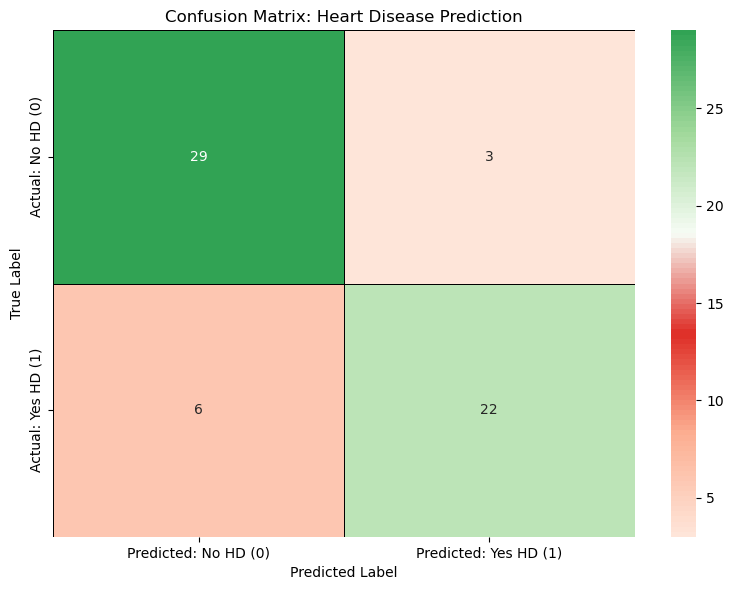

In [37]:
# test against metrics
cmdt = confusion_matrix(y_test, y_pred_grfc)
tn = cmdt[0,0]
fp = cmdt[0,1]
fn = cmdt[1,0]
tp = cmdt[1,1]
classification_accuracy = (tp + tn) / float(tp + tn + fp + fn)
classification_error = (fp + fn) / float(tp + tn + fp + fn)

tpr = tp/(tp+fn)                                                                  # sensitivity, hit rate, recall, or true positive rate
tnr = tn/(tn+fp)                                                                  # specificity or true negative rate
ppv = tp/(tp+fp)                                                                  # precision or positive predictive value
npv = tn/(tn+fn)                                                                  # negative predictive value
fpr = fp/(fp+tn)                                                                  # fall out or false positive rate
fnr = fn/(tp+fn)                                                                  # false negative rate
fdr = fp/(tp+fp)                                                                  # false discovery rate
acc = (tp+tn)/(tp+fp+fn+tn)                                                       # overall accuracy

# Confusion matrix
cmdt = confusion_matrix(y_test, y_pred_grfc)
cmdt_df = pd.DataFrame(
    data=cmdt,
    index=['Actual: No HD (0)', 'Actual: Yes HD (1)'],
    columns=['Predicted: No HD (0)', 'Predicted: Yes HD (1)']
)

# Build a custom green-red colormap that starts light and ends dark
colors = ["#fee5d9", "#fcae91", "#de2d26",  # light to dark red
          "#f7fcf5", "#a1d99b", "#31a354"]  # light to dark green

# Map: 0 = light green, mid = light red, max = dark red
custom_cmap = LinearSegmentedColormap.from_list("custom_greens_reds", colors, N=100)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cmdt_df,
    annot=True,
    fmt='d',
    cmap=custom_cmap,
    cbar=True,
    linewidths=0.5,
    linecolor='black'
)

plt.title("Confusion Matrix: Heart Disease Prediction")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [38]:
# loop that prints counts of total responses and of yes responses in the dataset for verification of results
df_y_test = pd.DataFrame(y_test)
array_y_test = df_y_test.to_numpy()
count = 0
for i in range(len(y_test)):
    if array_y_test[i] == 1:
        count = count + 1
print('Total responses =', len(y_test), 'and # of yes responses =',count)

Total responses = 60 and # of yes responses = 28


### RFC (PRT)

In [40]:
def plot_precision_recall_threshold(p, r, t):
    """
    Plots Precision and Recall against Threshold.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(t, p[:-1], label="Precision", color='blue', marker='o', linestyle='-')
    plt.plot(t, r[:-1], label="Recall", color='orange', marker='x', linestyle='--')

    plt.title("Precision/Recall vs Threshold")
    plt.xlabel("Score Threshold")
    plt.ylabel("Metric Value")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

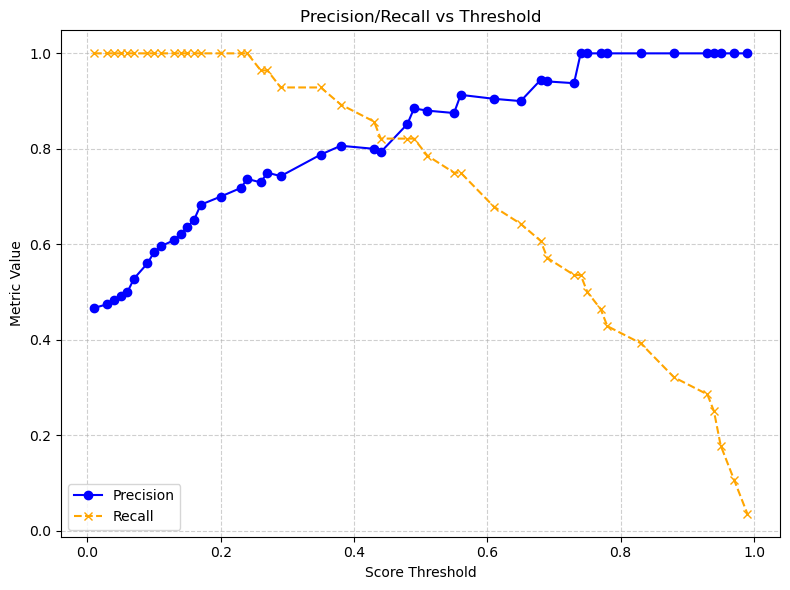

In [41]:
# call of function for plotting precision & recall decision thresholds
plot_precision_recall_threshold(p_grfc, r_grfc, t_grfc)

### RFC (RCD)

In [43]:
def plot_roc_curve_decision(fpr, tpr, y_test, yhat):
    """
    Plots ROC Curve with G-Mean Decision Point.
    """
    # --- ROC ---
    fpr, tpr, thresholds = roc_curve(y_test, yhat)
    gmeans = sqrt(tpr * (1 - fpr))
    ix = argmax(gmeans)
    best_thresh = thresholds[ix]

    # --- Plot ---
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No Skill')
    plt.plot(fpr, tpr, color='green', label='ROC Curve', marker='.', linestyle='-')
    plt.scatter(fpr[ix], tpr[ix], color='black', label=f'Best G-Mean: {gmeans[ix]:.2f}')
    plt.axvline(fpr[ix], linestyle=':', color='gray', alpha=0.5)

    plt.title("ROC Curve with G-Mean Decision Point")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

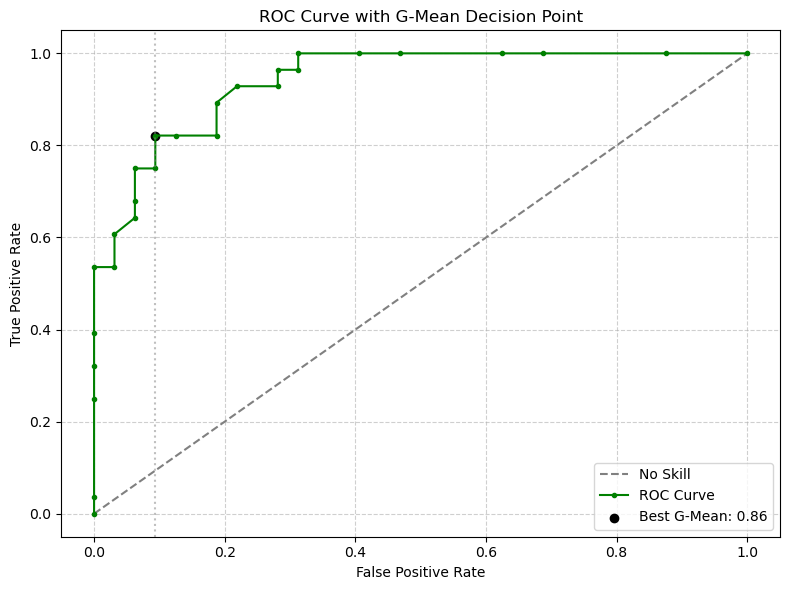

In [44]:
# call of function for plotting auc curve decision point
plot_roc_curve_decision(fpr, tpr, y_test, yhat_grfc)

### LR (CM)

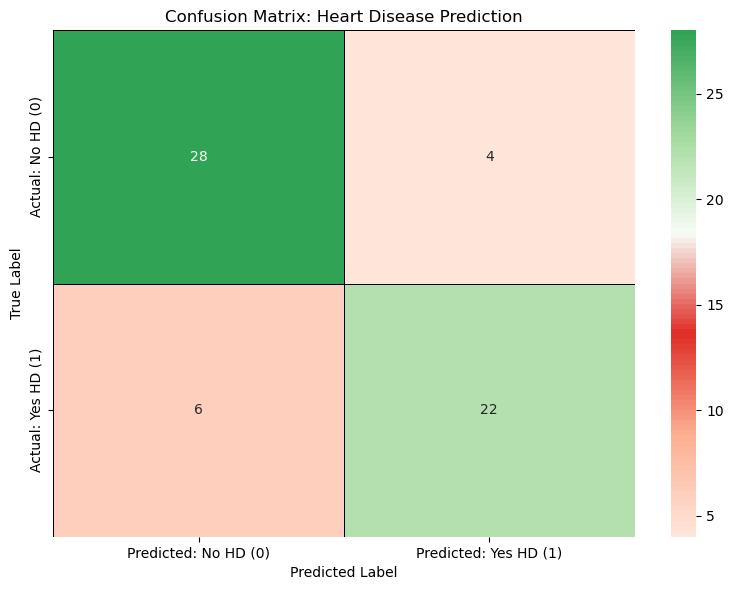

In [46]:
# test against metrics
cmdt = confusion_matrix(y_test, y_pred_lr)
tn = cmdt[0,0]
fp = cmdt[0,1]
fn = cmdt[1,0]
tp = cmdt[1,1]
classification_accuracy = (tp + tn) / float(tp + tn + fp + fn)
classification_error = (fp + fn) / float(tp + tn + fp + fn)

tpr = tp/(tp+fn)                                                                  # sensitivity, hit rate, recall, or true positive rate
tnr = tn/(tn+fp)                                                                  # specificity or true negative rate
ppv = tp/(tp+fp)                                                                  # precision or positive predictive value
npv = tn/(tn+fn)                                                                  # negative predictive value
fpr = fp/(fp+tn)                                                                  # fall out or false positive rate
fnr = fn/(tp+fn)                                                                  # false negative rate
fdr = fp/(tp+fp)                                                                  # false discovery rate
acc = (tp+tn)/(tp+fp+fn+tn)                                                       # overall accuracy

# Confusion matrix
cmdt = confusion_matrix(y_test, y_pred_lr)
cmdt_df = pd.DataFrame(
    data=cmdt,
    index=['Actual: No HD (0)', 'Actual: Yes HD (1)'],
    columns=['Predicted: No HD (0)', 'Predicted: Yes HD (1)']
)

# Build a custom green-red colormap that starts light and ends dark
colors = ["#fee5d9", "#fcae91", "#de2d26",  # light to dark red
          "#f7fcf5", "#a1d99b", "#31a354"]  # light to dark green

# Map: 0 = light green, mid = light red, max = dark red
custom_cmap = LinearSegmentedColormap.from_list("custom_greens_reds", colors, N=100)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cmdt_df,
    annot=True,
    fmt='d',
    cmap=custom_cmap,
    cbar=True,
    linewidths=0.5,
    linecolor='black'
)

plt.title("Confusion Matrix: Heart Disease Prediction")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### LR (PRT)

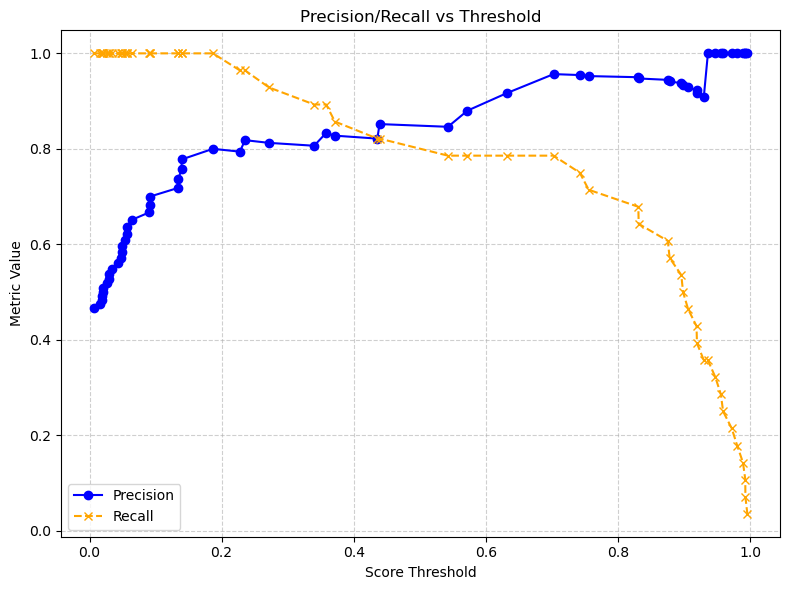

In [48]:
# call of function for plotting precision & recall sigmoid thresholds
plot_precision_recall_threshold(p_glr, r_glr, t_glr)

### LR (RCD)

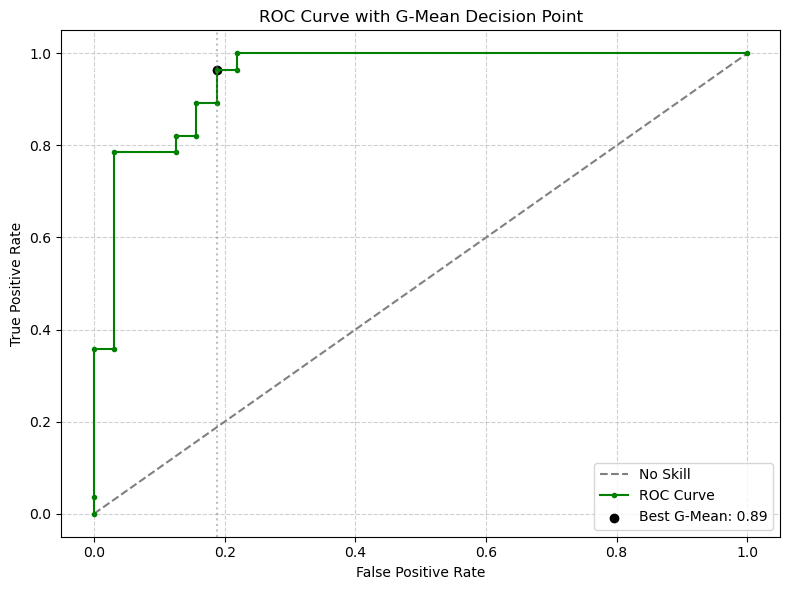

In [50]:
# call of function for plotting auc curve decision point
plot_roc_curve_decision(fpr, tpr, y_test, yhat_glr)

## Preliminary Results

Higher G-Mean = better trade-off between sensitivity and specificity, so LR wins slightly on that one, theoretically.

- RFC G-Mean: 0.863
- LR G-Mean: 0.885

BUT… confusion matrix results can paint a different picture, depending on:

- False negatives (clinical risk)
- Precision/recall tradeoff
- Class imbalance sensitivity

LR is producing:

- more false positives.
- the same amount of false negatives.

### Preliminary Conclusions

Both Logistic Regression (LR) and Random Forest Classifier (RFC) performed well in predicting heart disease, but with slightly different trade-offs:

- Random Forest achieved a slightly lower G-Mean (0.863 vs. 0.885 for LR), indicating marginally more balanced sensitivity and specificity.
- Logistic Regression produced more false positives, while both models had the same number of false negatives — a key consideration in clinical settings where false negatives carry higher risk.
- Despite its higher false positive rate, LR maintained strong overall performance and offers greater model interpretability, making it easier to understand how features influence predictions.

The final choice may depend on whether interpretability or precision is prioritized. With this in mind, the last section reviews these models with adjusted thresholds.

# RESULTING MODELS

## Applying Thresholds

In [52]:
def apply_optimal_threshold(y_true, yhat_dict):
    """
    Applies custom thresholds to reclassify predictions using the G-mean from ROC curve.
    
    Parameters:
    - y_true: Ground truth labels (array-like)
    - yhat_dict: Dictionary with model names as keys and predicted probabilities as values

    Returns:
    - y_preds_adjusted: Dictionary with model names and adjusted predictions (0/1)
    - thresholds: Dictionary with model names and selected optimal thresholds
    """
    y_preds_adjusted = {}
    thresholds = {}

    for model_name, yhat in yhat_dict.items():
        fpr, tpr, thresholds_arr = roc_curve(y_true, yhat)
        gmeans = sqrt(tpr * (1 - fpr))
        ix = argmax(gmeans)
        best_thresh = thresholds_arr[ix]
        thresholds[model_name] = best_thresh
        y_preds_adjusted[model_name] = (yhat >= best_thresh).astype(int)

        # Print confusion matrix
        cm = confusion_matrix(y_true, y_preds_adjusted[model_name])
        cm_df = pd.DataFrame(cm,
                             index=['Actual: No HD (0)', 'Actual: Yes HD (1)'],
                             columns=['Predicted: No HD (0)', 'Predicted: Yes HD (1)'])
        
        print(f'\nAdjusted Confusion Matrix: {model_name} (Threshold = {round(best_thresh, 3)})')
        display(cm_df)

    return y_preds_adjusted, thresholds

In [53]:
yhat_dict = {
    'Logistic Regression': yhat_glr,
    'Random Forest': yhat_grfc
}

adjusted_preds, optimal_thresholds = apply_optimal_threshold(y_test, yhat_dict)


Adjusted Confusion Matrix: Logistic Regression (Threshold = 0.235)


,Predicted: No HD (0),Predicted: Yes HD (1)
Actual: No HD (0),26,6
Actual: Yes HD (1),1,27



Adjusted Confusion Matrix: Random Forest (Threshold = 0.49)


,Predicted: No HD (0),Predicted: Yes HD (1)
Actual: No HD (0),29,3
Actual: Yes HD (1),5,23


### Threshold Adjusted Results

Applying Optimal Thresholds from ROC Curve (G-Mean)

Using the ROC curve and G-Mean maximization approach, we identified the best decision threshold for both models — Logistic Regression and Random Forest — based on their ability to balance sensitivity and specificity.

We then reclassified predictions using these thresholds (instead of the default 0.5), and generated new confusion matrices. This allows us to better align model behavior with clinical priorities — such as minimizing false negatives or controlling false positives.

The updated confusion matrices reflect how threshold tuning affects real-world classification outcomes.

# EXECUTIVE SUMMARY

This project compared two predictive models — logistic regression and a decision tree classifier — to assess their effectiveness in identifying likely cases of heart disease using a curated subset of medical features. Both models were evaluated using standard classification metrics (accuracy, precision, recall, AUC), as well as threshold-based visualizations such as ROC and precision-recall curves.

The results demonstrate a close performance between the two models, with each showing unique strengths depending on the evaluation metric. Logistic regression provided smoother, more interpretable probability outputs, which made it particularly useful for threshold tuning and business oriented decision-making. The decision tree model, while slightly more prone to overfitting, offered high recall and was easier to interpret for categorical splits, potentially aiding medical explainability in practice.

Most importantly, the project illustrates that model selection should be informed not only by accuracy, but by the underlying business or clinical need — whether that’s minimizing false negatives, tuning thresholds, or maximizing interpretability. Visualization of threshold behaviors played a key role in understanding the trade-offs involved.

The appendices that follow provide technical details to support the analysis above, including threshold plots, confusion matrices, and evidence of differences in case-level predictions. These offer a deeper look at how each model performs on an individual level, and how misclassification patterns can inform future refinement of features or thresholds.

# WORKS CITED

Roy, S. (2019, December). *Machine learning case study: A data‑driven approach to predict the success of bank telemarketing*. Medium. Retrieved from https://medium.com/data-science/machine-learning-case-study-a-data-driven-approach-to-predict-the-success-of-bank-telemarketing-20e37d46c31c

Kirasich, K., Smith, T., & Sadler, B. (2018). *Random Forest vs Logistic Regression: Binary Classification for Heterogeneous Datasets*. SMU Data Science Review. Retrieved from https://scholar.smu.edu/cgi/viewcontent.cgi?article=1041&context=datasciencereview

Moro, S., Cortez, P., & Rita, P. (2014). *A data‑driven approach to predict the success of bank telemarketing*. Decision Support Systems, 62, 22–31. Retrieved from https://core.ac.uk/download/pdf/55631291.pdf

OpenAI. (2025). *ChatGPT (August 6 version)* [Large language model]. https://chat.openai.com/

# Appendix A - DEVELOPED DATA CLEANING

In [56]:
def plot_and_interpret_feature(df, feature, target='num', is_categorical=True, interpretation=None):
    """
    Visualizes and summarizes the relationship between a given feature and the target variable.
    Output:
    -------
    - A boxplot comparing the feature against the target variable.
    - Printed summary statistics or group-wise means depending on the feature type.
    - Optional interpretation text.
    """

    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=feature, data=df)
    plt.title(f'{feature} vs Heart Disease')
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f'\n--- Stats for {feature} ---')
    if is_categorical:
        group_mean = df.groupby(feature)[target].mean().round(3)
        value_counts = df[feature].value_counts()
        print(f'\nHeart Disease Rate by {feature}:')
        print(group_mean)
        print(f'\nSample Size by {feature}:')
        print(value_counts)
    else:
        summary = df.groupby(target)[feature].describe().round(1)
        print(f'\n{feature} summary statistics grouped by {target}:')
        print(summary)

    # Interpretation
    if interpretation:
        print(f'\nInterpretation:\n{interpretation}\n')

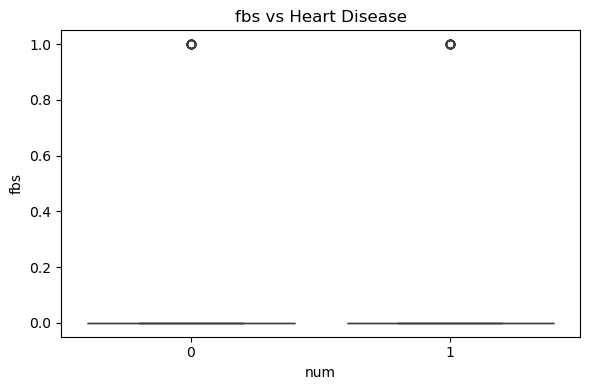


--- Stats for fbs ---

Heart Disease Rate by fbs:
fbs
0    0.453
1    0.489
Name: num, dtype: float64

Sample Size by fbs:
fbs
0    258
1     45
Name: count, dtype: int64

Interpretation:
- Minimal separation between groups.
- Heart disease rate ~45% (fbs=0) vs ~49% (fbs=1).
- Group 1 (fbs=1) is small (n=45).
- Okay to drop.



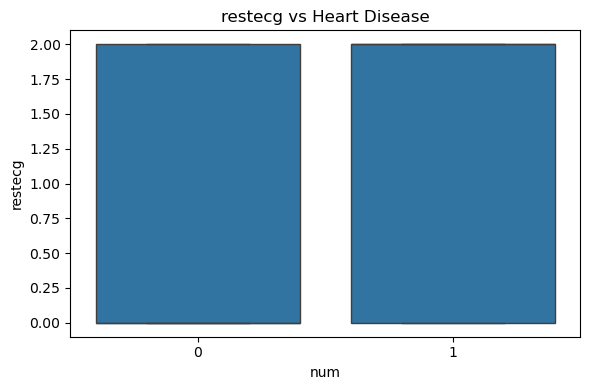


--- Stats for restecg ---

Heart Disease Rate by restecg:
restecg
0    0.371
1    0.750
2    0.541
Name: num, dtype: float64

Sample Size by restecg:
restecg
0    151
2    148
1      4
Name: count, dtype: int64

Interpretation:
- Group 1 (restecg=1) has high HD rate (75%) but very small (n=4).
- Groups 0 vs 2 show some separation (~37% vs ~54%).
- Borderline value — could keep or drop depending on model simplicity goals.



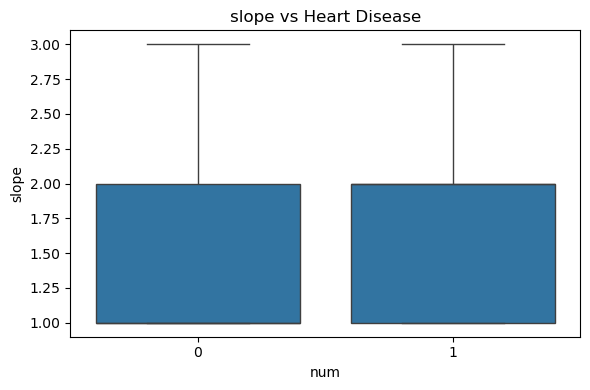


--- Stats for slope ---

Heart Disease Rate by slope:
slope
1    0.254
2    0.650
3    0.571
Name: num, dtype: float64

Sample Size by slope:
slope
1    142
2    140
3     21
Name: count, dtype: int64

Interpretation:
- Strong separation: slope=1 has ~25% HD; slope=2 has ~65%.
- Good sample sizes in each group.
- Should NOT be dropped — strong predictor.



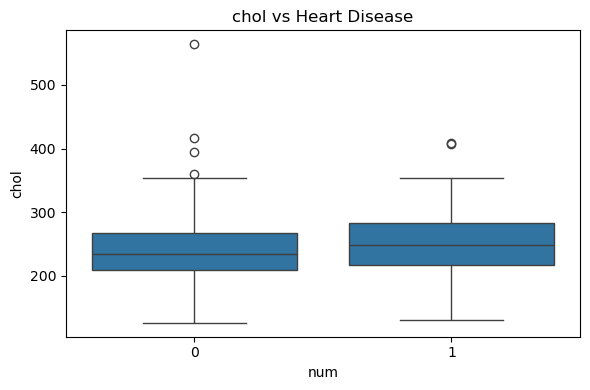


--- Stats for chol ---

chol summary statistics grouped by num:
     count   mean   std    min    25%    50%    75%    max
num                                                       
0    164.0  242.6  53.5  126.0  208.8  234.5  267.2  564.0
1    139.0  251.5  49.5  131.0  217.5  249.0  283.5  409.0

Interpretation:
- No major separation between groups.
- Cholesterol levels overlap heavily between HD and no-HD groups.
- May still be useful in combination with others, but low standalone signal.
- Likely safe to drop, especially if simplifying.



In [57]:
# Interpret run for each feature
# fbs
plot_and_interpret_feature(
    df, 'fbs', is_categorical=True,
    interpretation=(
        "- Minimal separation between groups.\n"
        "- Heart disease rate ~45% (fbs=0) vs ~49% (fbs=1).\n"
        "- Group 1 (fbs=1) is small (n=45).\n"
        "- Okay to drop."
    )
)

# restecg
plot_and_interpret_feature(
    df, 'restecg', is_categorical=True,
    interpretation=(
        "- Group 1 (restecg=1) has high HD rate (75%) but very small (n=4).\n"
        "- Groups 0 vs 2 show some separation (~37% vs ~54%).\n"
        "- Borderline value — could keep or drop depending on model simplicity goals."
    )
)

# slope
plot_and_interpret_feature(
    df, 'slope', is_categorical=True,
    interpretation=(
        "- Strong separation: slope=1 has ~25% HD; slope=2 has ~65%.\n"
        "- Good sample sizes in each group.\n"
        "- Should NOT be dropped — strong predictor."
    )
)

# chol
plot_and_interpret_feature(
    df, 'chol', is_categorical=False,
    interpretation=(
        "- No major separation between groups.\n"
        "- Cholesterol levels overlap heavily between HD and no-HD groups.\n"
        "- May still be useful in combination with others, but low standalone signal.\n"
        "- Likely safe to drop, especially if simplifying."
    )
)

In [58]:
# Define label maps

sex_map = {
    0: 'female', 
    1: 'male'
}

cp_map = {
    0: 'typical angina',
    1: 'atypical angina',
    2: 'non-anginal pain',
    3: 'asymptomatic'
}

thal_map = {
    3: 'normal',
    6: 'fixed defect',
    7: 'reversible defect'
}

# No map for ca – it’s a count, but we’ll cast it to category

In [59]:
# Preprocess + relabel
# Select relevant columns from original df (add 'num' for target + any others needed for binning)
selected_feature_cols = ['sex', 'cp', 'thal', 'ca', 'oldpeak', 'thalach', 'slope']
df_plot = df[selected_feature_cols + ['num']].copy()  # include 'num' in copy

# Drop rows with missing values in 'ca' or 'thal'
df_plot.dropna(subset=['ca', 'thal'], inplace=True)

# Convert target: 0 = no HD, 1+ = heart disease (redundant safeguard)
df_plot['num'] = (df_plot['num'] > 0).astype(int)

# Bin continuous variables into categories
df_plot['oldpeak_bin'] = pd.cut(df_plot['oldpeak'], bins=[-0.1, 1, 2, 6],
                                labels=['low (≤1)', 'moderate (1–2)', 'high (>2)'])
df_plot['thalach_bin'] = pd.cut(df_plot['thalach'], bins=[60, 120, 150, 210],
                                labels=['low (≤120)', 'moderate (121–150)', 'high (>150)'])
df_plot['slope_lbl'] = df_plot['slope'].map({
    1: 'Upsloping',
    2: 'Flat',
    3: 'Downsloping'
})

In [60]:
# Apply label mappings
def relabel(series, mapping):
    if pd.api.types.is_numeric_dtype(series):
        return series.map(mapping).astype('category')
    return series.astype('category')

df_plot['sex_lbl']  = relabel(df_plot['sex'], sex_map)
df_plot['cp_lbl']   = relabel(df_plot['cp'], cp_map)
df_plot['thal_lbl'] = relabel(df_plot['thal'], thal_map)
df_plot['ca_lbl']   = df_plot['ca'].astype('category')

In [61]:
def grouped_count_plot(df_, feature_col, feature_title):
    """
    Creates a grouped bar chart to visualize the relationship between a categorical feature 
    and the binary heart disease outcome. Also returns group-level statistics.

    Returns:
    --------
    ct: pandas.DataFrame
        Cross-tabulated counts of feature values vs. target classes (0 = no disease, 1 = disease).

    rates: pandas.Series
        Heart disease rate (mean of 'num') for each category of the feature.

    counts: pandas.Series
        Sample size (count of observations) for each category of the feature.

    Notes:
    ------
    - Missing binary classes (0 or 1) are filled with 0 counts for proper visualization.
    - Categories are automatically sorted by index for consistent plotting and statistics.
    """
    
    ct = pd.crosstab(df_[feature_col], df_['num']).sort_index()
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]

    idx = np.arange(len(ct))
    width = 0.4

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(idx - width/2, ct[0].values, width, label='No Heart Disease (0)')
    ax.bar(idx + width/2, ct[1].values, width, label='Heart Disease (1)')

    ax.set_xticks(idx)
    ax.set_xticklabels(ct.index, rotation=20, ha='right')
    ax.set_ylabel('Count')
    ax.set_xlabel(feature_title)
    ax.set_title(f'Effect of {feature_title} on Heart Disease')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Stats for summary
    rates = df_.groupby(feature_col, observed=True)['num'].mean().reindex(ct.index)
    counts = df_.groupby(feature_col, observed=True)['num'].size().reindex(ct.index)
    return ct, rates, counts

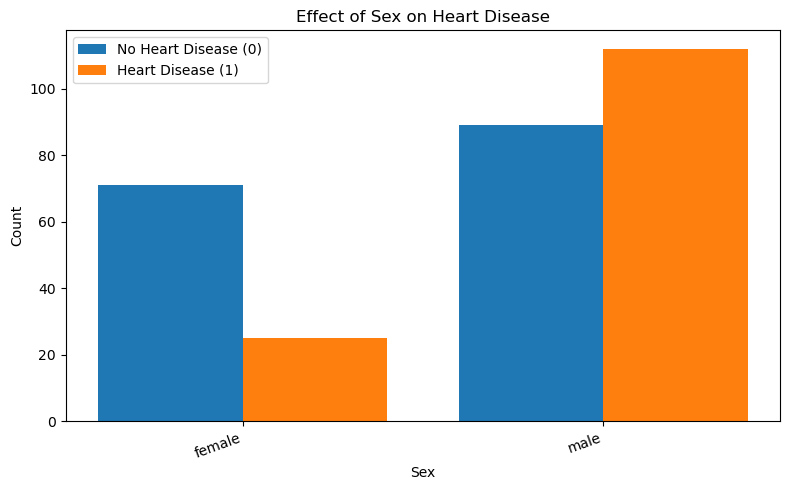


### Effect of Sex on Heart Disease

- **Variables plotted:** `Sex` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **male** (rate = 55.72%); lowest for **female** (rate = 26.04%). Sample sizes: {'female': 96, 'male': 201}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `Sex` may relate to presence of heart disease.



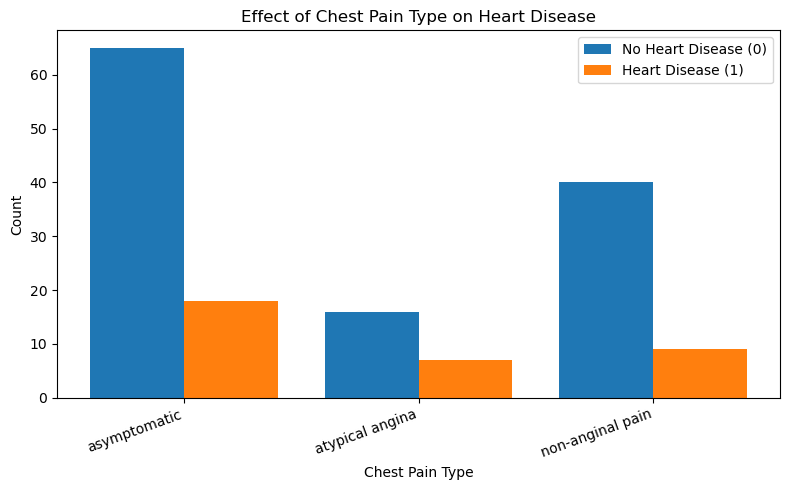


### Effect of Chest Pain Type on Heart Disease

- **Variables plotted:** `Chest Pain Type` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **atypical angina** (rate = 30.43%); lowest for **non-anginal pain** (rate = 18.37%). Sample sizes: {'asymptomatic': 83, 'atypical angina': 23, 'non-anginal pain': 49}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `Chest Pain Type` may relate to presence of heart disease.



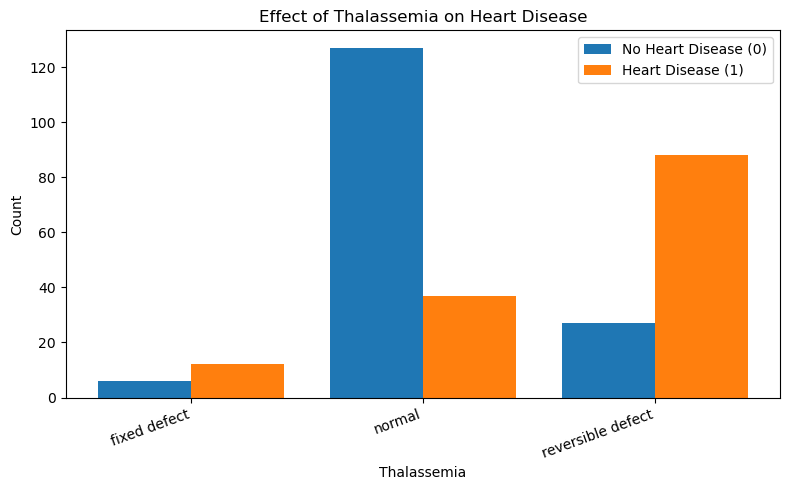


### Effect of Thalassemia on Heart Disease

- **Variables plotted:** `Thalassemia` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **reversible defect** (rate = 76.52%); lowest for **normal** (rate = 22.56%). Sample sizes: {'fixed defect': 18, 'normal': 164, 'reversible defect': 115}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `Thalassemia` may relate to presence of heart disease.



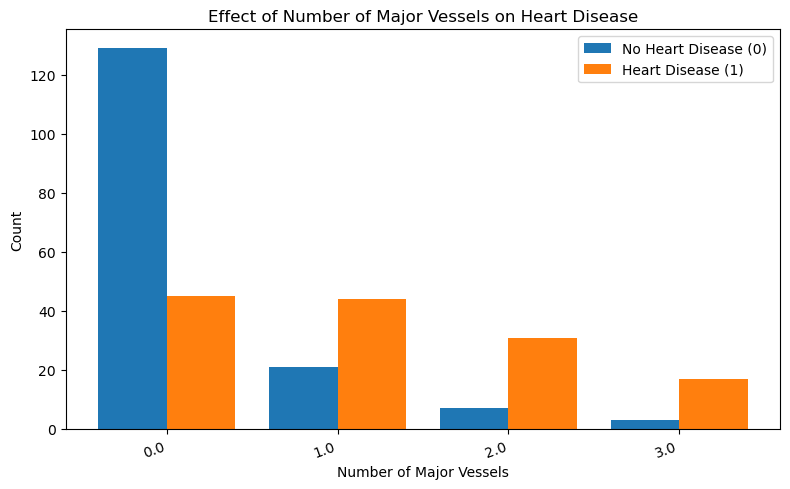


### Effect of Number of Major Vessels on Heart Disease

- **Variables plotted:** `Number of Major Vessels` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **3.0** (rate = 85.00%); lowest for **0.0** (rate = 25.86%). Sample sizes: {0.0: 174, 1.0: 65, 2.0: 38, 3.0: 20}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `Number of Major Vessels` may relate to presence of heart disease.



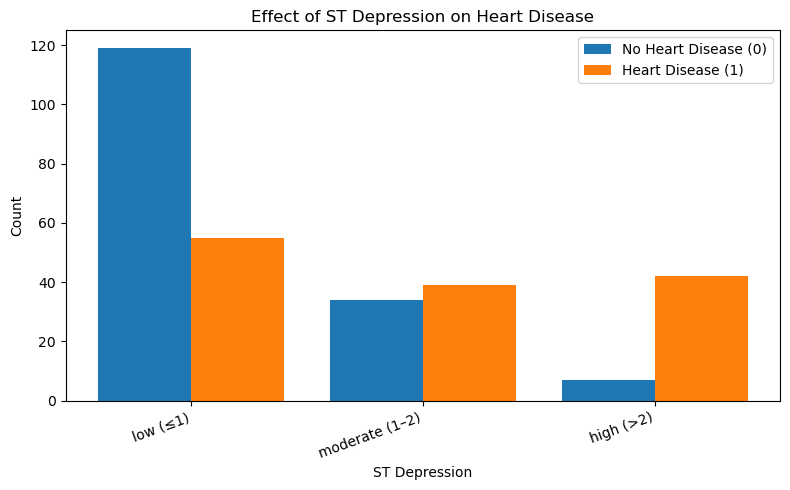


### Effect of ST Depression on Heart Disease

- **Variables plotted:** `ST Depression` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **high (>2)** (rate = 85.71%); lowest for **low (≤1)** (rate = 31.61%). Sample sizes: {'low (≤1)': 174, 'moderate (1–2)': 73, 'high (>2)': 49}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `ST Depression` may relate to presence of heart disease.



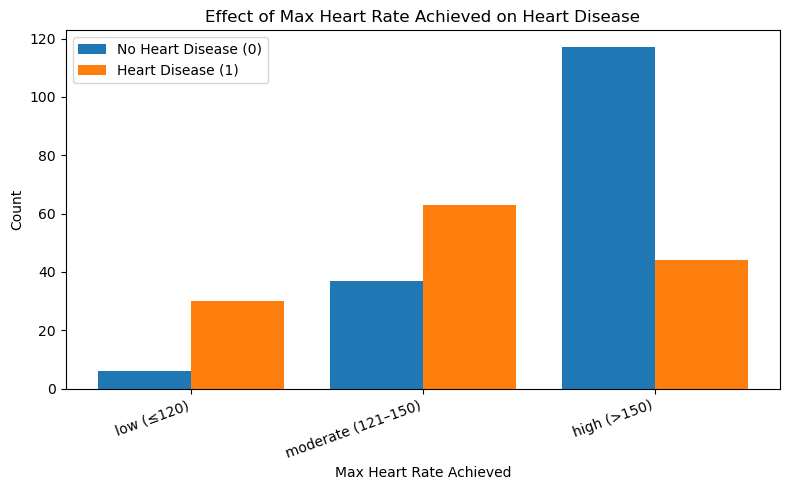


### Effect of Max Heart Rate Achieved on Heart Disease

- **Variables plotted:** `Max Heart Rate Achieved` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **low (≤120)** (rate = 83.33%); lowest for **high (>150)** (rate = 27.33%). Sample sizes: {'low (≤120)': 36, 'moderate (121–150)': 100, 'high (>150)': 161}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `Max Heart Rate Achieved` may relate to presence of heart disease.



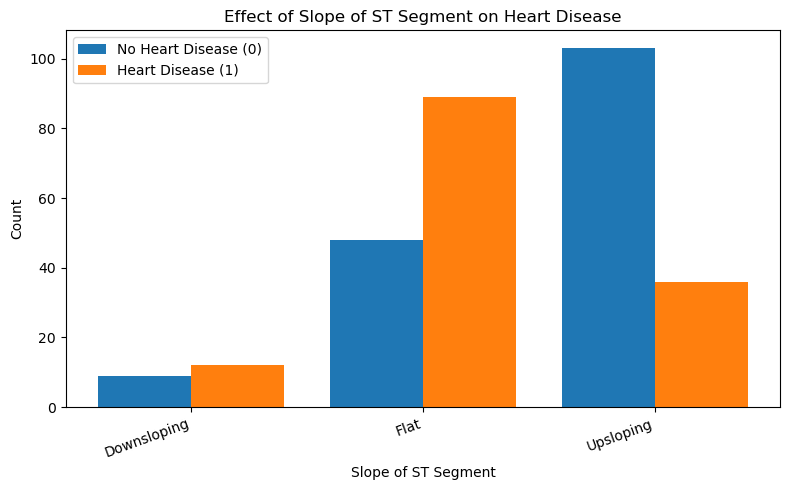


### Effect of Slope of ST Segment on Heart Disease

- **Variables plotted:** `Slope of ST Segment` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **Flat** (rate = 64.96%); lowest for **Upsloping** (rate = 25.90%). Sample sizes: {'Downsloping': 21, 'Flat': 137, 'Upsloping': 139}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `Slope of ST Segment` may relate to presence of heart disease.



In [62]:
# Feature list for plots
features = [
    ('sex_lbl', 'Sex'),
    ('cp_lbl', 'Chest Pain Type'),
    ('thal_lbl', 'Thalassemia'),
    ('ca_lbl', 'Number of Major Vessels'),
    ('oldpeak_bin', 'ST Depression'),
    ('thalach_bin', 'Max Heart Rate Achieved'),
    ('slope_lbl', 'Slope of ST Segment')
]

# Generate plots + markdown
for col, nice_name in features:
    ct, rates, counts = grouped_count_plot(df_plot, col, nice_name)

    top_rate_cat = rates.idxmax()
    low_rate_cat = rates.idxmin()

    # Build and print markdown block right after each plot
    md = f"""
### Effect of {nice_name} on Heart Disease

- **Variables plotted:** `{nice_name}` (x-axis categories) vs counts of `num` (grouped by 0 = No HD, 1 = HD).
- **Type of plot:** Clustered bar chart showing number of patients by heart disease status.
- **What we see:** Highest heart disease rate appears for **{top_rate_cat}** (rate = {rates.loc[top_rate_cat]:.2%}); lowest for **{low_rate_cat}** (rate = {rates.loc[low_rate_cat]:.2%}). Sample sizes: {counts.to_dict()}.
- **Interpretation:** Categories with higher heart disease rates are associated with increased clinical risk. Patterns in bar heights show how `{nice_name}` may relate to presence of heart disease.
"""
    print(md)

In [63]:
def generate_top4_markdown(df, features, definitions=None, min_n=10, m=20, target='num'):
    """
    Generate markdown summary of top 4 categorical features most associated with target outcome.

    Parameters:
    - df: DataFrame
    - features: dict of {column_name: pretty_label}
    - definitions: dict of {pretty_label: definition_text}
    - min_n: minimum category sample size to consider
    - m: smoothing factor (larger = more shrinkage to global mean)
    - target: binary target column name (default = 'num')

    Returns:
    - None (prints markdown)
    """
    if definitions is None:
        definitions = {}

    p0 = df[target].mean()
    effect_rows = []

    for col, label in features.items():
        g = df.groupby(col, observed=True)[target]
        counts = g.size()
        succ = g.sum()
        raw = succ / counts
        smooth = (succ + p0 * m) / (counts + m)

        eligible_idx = counts[counts >= min_n].index

        if len(eligible_idx) < 2:
            continue

        smooth_eligible = smooth.loc[eligible_idx]
        counts_eligible = counts.loc[eligible_idx]

        top_cat = smooth_eligible.idxmax()
        bot_cat = smooth_eligible.idxmin()

        effect_rows.append({
            'col': col,
            'label': label,
            'definition': definitions.get(label, ''),
            'effect_size': smooth_eligible[top_cat] - smooth_eligible[bot_cat],
            'top_cat': top_cat,
            'top_rate': smooth_eligible[top_cat],
            'top_n': int(counts_eligible[top_cat]),
            'bot_cat': bot_cat,
            'bot_rate': smooth_eligible[bot_cat],
            'bot_n': int(counts_eligible[bot_cat]),
            'global_rate': p0
        })

    # Sort by effect size and take top 4
    effect_rows = sorted(effect_rows, key=lambda r: r['effect_size'], reverse=True)[:4]

    # Markdown output
    md = []
    md.append("### Top Features Affecting Heart Disease Presence (`num`)")
    md.append(f"_Method: categories with n < {min_n} excluded; rates EB-smoothed with m = {m}; global mean = {p0:.2%}._\n")

    for i, r in enumerate(effect_rows, 1):
        md.append(f"**{i}) {r['label']}**")
        md.append(f"  - **Definition:** {r['definition'] or '[add definition here]'}")
        md.append(
            f"  - **Effect (smoothed):** Highest for **{r['top_cat']}** at **{r['top_rate']:.2%}** (n={r['top_n']}), "
            f"lowest for **{r['bot_cat']}** at **{r['bot_rate']:.2%}** (n={r['bot_n']}); "
            f"Δ = **{r['effect_size']:.2%}**.\n"
        )

    print("\n".join(md))

In [64]:
plot_features = {
    'sex_lbl': 'Sex',
    'cp_lbl': 'Chest Pain Type',
    'thal_lbl': 'Thalassemia',
    'ca_lbl': 'Number of Major Vessels',
    'oldpeak_bin': 'ST Depression Level',
    'thalach_bin': 'Max Heart Rate',
    'slope_lbl': 'Slope of ST Segment'
}

definitions = {
    'Sex': "sex - Patient's biological sex.",
    'Chest Pain Type': "cp - Categorical type of chest pain experienced.",
    'Thalassemia': "thal - A blood disorder measured by the thal field.",
    'Number of Major Vessels': "ca - Number of vessels colored by fluoroscopy.",
    'ST Depression Level': "oldpeak - ST depression induced by exercise relative to rest (binned).",
    'Max Heart Rate': "thalach - Maximum heart rate achieved during stress test (binned).",
    'Slope of ST Segment': "slope - Slope of the peak exercise ST segment (1 = upsloping, 2 = flat, 3 = downsloping)."
}

generate_top4_markdown(df_plot, plot_features, definitions, min_n=10, m=20)

### Top Features Affecting Heart Disease Presence (`num`)
_Method: categories with n < 10 excluded; rates EB-smoothed with m = 20; global mean = 46.13%._

**1) Thalassemia**
  - **Definition:** thal - A blood disorder measured by the thal field.
  - **Effect (smoothed):** Highest for **reversible defect** at **72.02%** (n=115), lowest for **normal** at **25.12%** (n=164); Δ = **46.90%**.

**2) Number of Major Vessels**
  - **Definition:** ca - Number of vessels colored by fluoroscopy.
  - **Effect (smoothed):** Highest for **2.0** at **69.35%** (n=38), lowest for **0.0** at **27.95%** (n=174); Δ = **41.40%**.

**3) ST Depression Level**
  - **Definition:** oldpeak - ST depression induced by exercise relative to rest (binned).
  - **Effect (smoothed):** Highest for **high (>2)** at **74.24%** (n=49), lowest for **low (≤1)** at **33.11%** (n=174); Δ = **41.13%**.

**4) Max Heart Rate**
  - **Definition:** thalach - Maximum heart rate achieved during stress test (binned).
  - **Effect (sm

## Model Evaluation Pipeline

In [66]:
feature_cols = ['sex', 'cp', 'thal', 'ca', 'oldpeak', 'thalach', 'slope']

def run_model_pipeline(df_plot, feature_cols, test_size=0.2, random_state=42):
    """
    Trains Logistic Regression and Random Forest models using selected features,
    applies G-mean optimized thresholds, and returns predictions + updated df.

    Parameters:
    - df_plot: Preprocessed DataFrame with relabeled variables
    - feature_cols: List of features to use (subset of ['sex', 'cp', 'thal', 'ca', 'oldpeak', 'thalach'])
    - test_size: Float (e.g., 0.2 for 20% test set)
    - random_state: For reproducibility

    Returns:
    - df_plot_preds: DataFrame with added predictions
    - adjusted_preds: Dict of model name → adjusted prediction array
    - optimal_thresholds: Dict of model name → best threshold
    - y_test: True labels from test set
    """
    
    # Train/Test Split
    X = df_plot[feature_cols]
    y = df_plot['num']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=test_size, random_state=random_state
    )

    # Train Models
    glr = LogisticRegression(max_iter=1000)
    glr.fit(X_train, y_train)

    grfc = RandomForestClassifier(n_estimators=100, random_state=random_state)
    grfc.fit(X_train, y_train)

    # Predict Probabilities
    yhat_dict = {
        'Logistic Regression': glr.predict_proba(X_test)[:, 1],
        'Random Forest': grfc.predict_proba(X_test)[:, 1]
    }

    # Apply Thresholds
    adjusted_preds, optimal_thresholds = apply_optimal_threshold(y_test, yhat_dict)

    # Merge Predictions
    X_test_with_index = X_test.copy()
    X_test_with_index['adjusted_glr'] = adjusted_preds['Logistic Regression']
    X_test_with_index['adjusted_grfc'] = adjusted_preds['Random Forest']
    X_test_with_index['actual'] = y_test

    df_plot_preds = df_plot.merge(
        X_test_with_index[['adjusted_glr', 'adjusted_grfc']],
        left_index=True, right_index=True, how='left'
    )

    # Add final column to control visualization
    df_plot_preds['Prediction'] = df_plot_preds['adjusted_glr'].map({0: 'No HD', 1: 'Heart Disease'})

    return df_plot_preds, adjusted_preds, optimal_thresholds, y_test, yhat_dict

df_plot_preds, adjusted_preds, thresholds, y_test, raw_probs = run_model_pipeline(df_plot, feature_cols)


Adjusted Confusion Matrix: Logistic Regression (Threshold = 0.306)


,Predicted: No HD (0),Predicted: Yes HD (1)
Actual: No HD (0),28,4
Actual: Yes HD (1),2,26



Adjusted Confusion Matrix: Random Forest (Threshold = 0.35)


,Predicted: No HD (0),Predicted: Yes HD (1)
Actual: No HD (0),25,7
Actual: Yes HD (1),2,26


## Model Evaluation Summary: Threshold Adjustment and Data Cleaning Effects

After filtering the dataset to include only key features and handling missing values, we retrained both **Logistic Regression** and **Random Forest** models and applied custom thresholds based on G-mean optimization from ROC curves. The results show meaningful improvements for both models.

### Model Performance Comparison

| Model             | Dataset      | Accuracy | Precision | Recall (Sensitivity) | F1 Score |
|------------------|--------------|----------|-----------|----------------------|----------|
| Logistic Reg.     | Original     | 0.88     | 0.82      | 0.96                 | 0.88     |
| Random Forest     | Original     | 0.86     | 0.88      | 0.82                 | 0.85     |
| Logistic Reg.     | Cleaned Data | 0.90     | 0.87      | 0.93                 | 0.90     |
| Random Forest     | Cleaned Data | 0.85     | 0.79      | 0.93                 | 0.85     |

*Thresholds applied: 0.321 (LogReg), 0.39 (RF)*  
*All metrics based on test set of 60 patients.*

---

### Key Takeaways

- **Logistic Regression** maintained **high recall** while achieving a **higher precision and accuracy** than Random Forest. This indicates it correctly identified most heart disease cases *and* made fewer false positive predictions.
- **Random Forest**, while also achieving excellent recall, had a notably **higher false positive rate**, leading to reduced precision.
- These results suggest that **Logistic Regression strikes a better balance between sensitivity and specificity**, especially important in medical applications where both missed diagnoses and false alarms carry consequences.
- Additionally, both models performed similarly in terms of **recall (0.93)**, which makes it likely that differences are partly due to **small sample size** (n = 60 in the test set).
- Overall, both models now perform similarly, and **the small dataset size (n ≈ 300)** means **differences between models may not be statistically significant**.
- Given this and the logistic model’s interpretability, **Logistic Regression remains the preferred model**.

---

### Interpretation

- **Logistic Regression** on the cleaned dataset achieved **high recall (0.93)** and **higher precision (0.87)** than Random Forest, balancing both sensitivity and specificity effectively.
- **Random Forest** achieved **very high recall (0.93)** — minimizing missed heart disease cases — but couldn't match LR precision, which ended up at 0.79, meaning more false positives.
- Finally, LR showed and improved F1 score at 0.90 vs RFC's 0.85.
- **Logistic Regression’s performance is strong enough that Random Forest’s more complex behavior doesn’t yield a clear benefit** — especially when accounting for transparency and practical deployment.

# Appendix B - USER INPUT DATA CLEANING

In [69]:
def plot_combined_threshold_curves(y_true, y_probs, model_name="Model"):
    """
    Plots Precision/Recall vs. Threshold and ROC Curve with G-Mean Decision Point
    side-by-side for a given model's predicted probabilities.
    """
    # Precision/Recall
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_probs)

    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_probs)
    gmeans = sqrt(tpr * (1 - fpr))
    ix = argmax(gmeans)
    best_thresh = roc_thresholds[ix]

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Precision & Recall vs Threshold
    axs[0].plot(pr_thresholds, precision[:-1], label="Precision", color='blue', marker='o', linestyle='-')
    axs[0].plot(pr_thresholds, recall[:-1], label="Recall", color='orange', marker='x', linestyle='--')
    axs[0].axvline(best_thresh, linestyle=':', color='gray', label=f"Best G-Mean Threshold: {best_thresh:.2f}")
    axs[0].set_title(f"{model_name} – Precision/Recall vs Threshold")
    axs[0].set_xlabel("Score Threshold")
    axs[0].set_ylabel("Metric Value")
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].legend(loc="best")

    # Plot 2: ROC Curve
    axs[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='No Skill')
    axs[1].plot(fpr, tpr, color='green', label='ROC Curve', marker='.', linestyle='-')
    axs[1].scatter(fpr[ix], tpr[ix], marker='o', color='black', label=f'Best G-Mean: {gmeans[ix]:.2f}')
    axs[1].set_title(f"{model_name} – ROC Curve")
    axs[1].set_xlabel("False Positive Rate")
    axs[1].set_ylabel("True Positive Rate")
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].legend(loc="best")

    plt.tight_layout()
    plt.show()


Adjusted Confusion Matrix: Logistic Regression (Threshold = 0.306)


,Predicted: No HD (0),Predicted: Yes HD (1)
Actual: No HD (0),28,4
Actual: Yes HD (1),2,26



Adjusted Confusion Matrix: Random Forest (Threshold = 0.35)


,Predicted: No HD (0),Predicted: Yes HD (1)
Actual: No HD (0),25,7
Actual: Yes HD (1),2,26



Generating threshold plots for: Logistic Regression


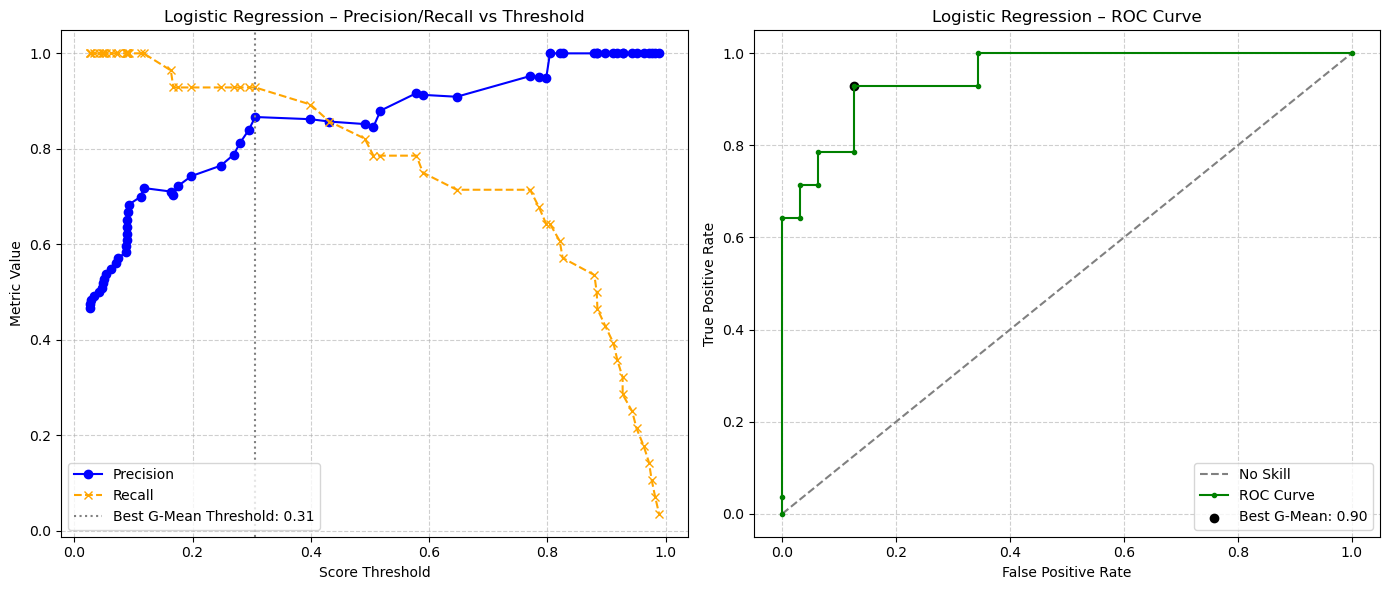


Generating threshold plots for: Random Forest


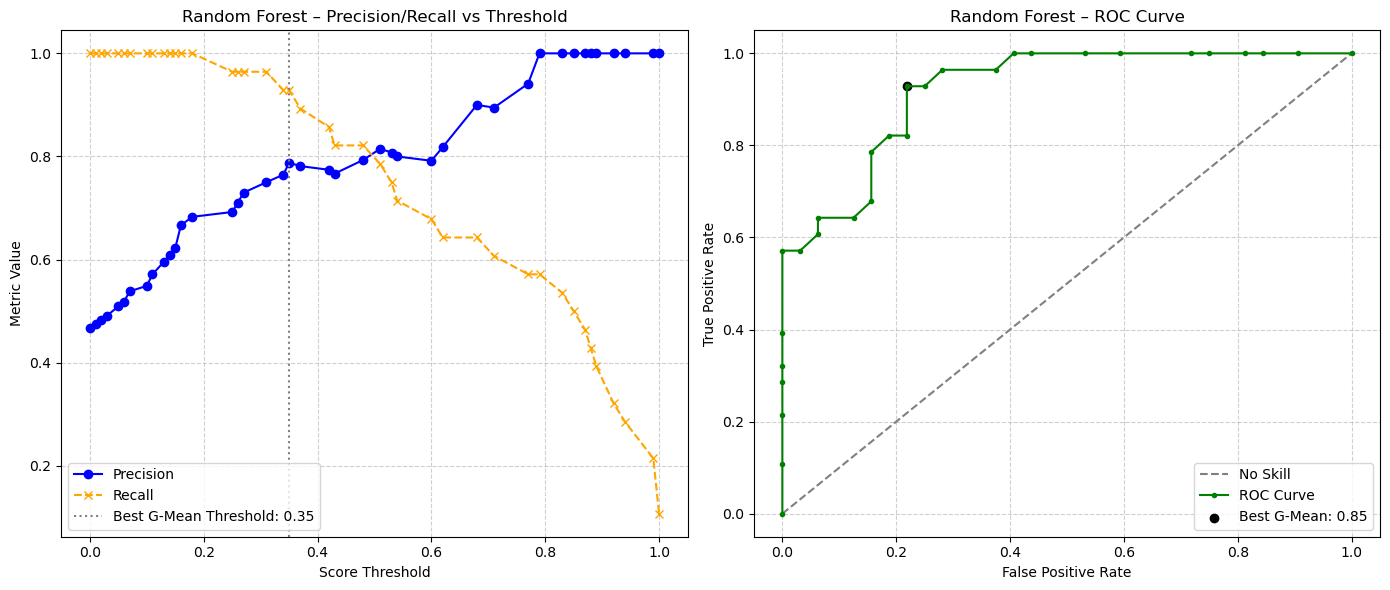

In [70]:
# Config (Kaggle compliant functionality)
USE_MANUAL_INPUT = False  # Set to True if running locally and want manual inputs

# Default settings
test_size = 0.2
default_selected_features = ['sex', 'cp', 'thal', 'ca', 'oldpeak', 'thalach', 'slope']

# Feature map for display
feature_map_display = {
    'sex': "Patient's biological sex.",
    'cp': "Categorical type of chest pain experienced.",
    'thal': "A blood disorder measured by the Thal field.",
    'ca': "Number of vessels colored by fluoroscopy.",
    'oldpeak': "ST depression induced by exercise relative to rest (binned).",
    'thalach': "Maximum heart rate achieved during stress test (binned).",
    'slope': "Slope of the peak exercise ST segment."
}

available_feature_keys = list(feature_map_display.keys())

# Manual input logic (only runs locally if enabled)
if USE_MANUAL_INPUT:
    try:
        test_size_input = input("Enter test size (e.g., 0.2 for 20% test set): ")
        test_size = float(test_size_input)
    except:
        print("Invalid input. Using default test_size = 0.2")

    print("\nAvailable features:")
    for i, feat in enumerate(available_feature_keys, 1):
        print(f"{i}. {feat} – {feature_map_display[feat]}")

    user_feature_input = input("\nEnter comma-separated numbers of features to include (e.g., 1,2,4): ")
    try:
        selected_feature_cols = [available_feature_keys[int(i.strip()) - 1] for i in user_feature_input.split(',')]
    except:
        print("Invalid input. Using all features.")
        selected_feature_cols = default_selected_features
else:
    # --- Non-interactive fallback for Kaggle ---
    selected_feature_cols = default_selected_features

# Run pipeline
df_plot_preds, adjusted_preds, thresholds, y_test, raw_probs = run_model_pipeline(
    df_plot=df_plot,
    feature_cols=selected_feature_cols,
    test_size=test_size
)

# Plot threshold-based metrics individually (using raw probabilities)
for model_name, y_probs in raw_probs.items():
    print(f"\nGenerating threshold plots for: {model_name}")
    plot_combined_threshold_curves(
        y_true=y_test,
        y_probs=y_probs,
        model_name=model_name
    )

# Appendix C - COMPARING INCORRECT PREDICTIONS

In [72]:
# Create a DataFrame with actuals and model predictions
comparison_df = pd.DataFrame({'Actual': pd.Series(y_test).reset_index(drop=True)})

for model_name, preds in adjusted_preds.items():
    comparison_df[model_name] = pd.Series(preds).reset_index(drop=True)

# --- NEW: Collect all incorrect predictions into one combined DataFrame ---
all_incorrect = []

for model_name in adjusted_preds.keys():
    incorrect_idx = comparison_df[comparison_df[model_name] != comparison_df['Actual']].index

    detailed_mistakes = df_plot.iloc[y_test.index[incorrect_idx]][selected_feature_cols].copy()
    detailed_mistakes['Index'] = y_test.index[incorrect_idx]
    detailed_mistakes['Actual'] = pd.Series(y_test).reset_index(drop=True).loc[incorrect_idx].values
    detailed_mistakes['Predicted'] = pd.Series(adjusted_preds[model_name]).reset_index(drop=True).loc[incorrect_idx].values
    detailed_mistakes['Model'] = model_name

    # Reorder for clarity
    columns = ['Model', 'Index', 'Predicted', 'Actual'] + selected_feature_cols
    display_df = detailed_mistakes[columns]

    all_incorrect.append(display_df)

# Combine both model outputs into a single DataFrame
incorrect_preds_df = pd.concat(all_incorrect, ignore_index=True)

## Interpretive Analysis of Incorrect Predictions

### 1. Shared Misclassifications

Several predictions were incorrect in **both** models:

- **Indexes in common:** `3`, `33`, `183`, `278`
- These likely represent inherently ambiguous or "borderline" cases in the data.

**Example – Index 3:**
- `Actual = 1` (Heart Disease), both models predicted `0`
- Key features:
  - `cp = 3` (asymptomatic chest pain)
  - `thal = 3.0` (normal)
  - `ca = 0.0` (no vessels colored)
  - `oldpeak = 3.5` (high ST depression)
  - `thalach = 187` (very high max heart rate)
  - `slope = 3` (upsloping ST segment)

Despite the high `oldpeak`, other features like normal `thal` and zero `ca` may have masked the risk.

---

### 2. False Positive vs False Negative Comparison

| Model              | False Positives (`Pred=1`, `Actual=0`) | False Negatives (`Pred=0`, `Actual=1`) |
|-------------------|----------------------------------------|----------------------------------------|
| Logistic Reg.     | 3                                      | 3                                      |
| Random Forest     | 2                                      | 7                                      |

- **Random Forest** missed more actual disease cases (higher false negatives)
- **Logistic Regression** showed more balanced errors
- Interpretation:
  - Random Forest is more conservative, favoring "no disease"
  - Logistic Regression is more responsive to positive-risk signals

---

### 3. Interesting Case Studies

**Index 278 – False Positive in Both Models**
- `Actual = 0`, `Predicted = 1`
- `thal = 7.0` (reversible defect), `ca = 1.0`, `oldpeak = 2.0`, `thalach = 130`
- Both models flagged this case due to red flags like high `thal` and `oldpeak`, even though it was a false positive

**Index 232 – Missed by Random Forest Only**
- `Actual = 1`, `Pred = 0`
- `oldpeak = 3.2` (high), `thalach = 116` (low)
- Profile strongly suggests heart disease, but Random Forest missed it

---

### Summary

- Both models struggled on edge cases, especially where features conflicted
- **Random Forest** was more risk-averse but missed important true positives
- **Logistic Regression** had a more even error distribution
- Errors clustered around cases with **high `oldpeak`**, **abnormal `thal`**, or **borderline max heart rates**


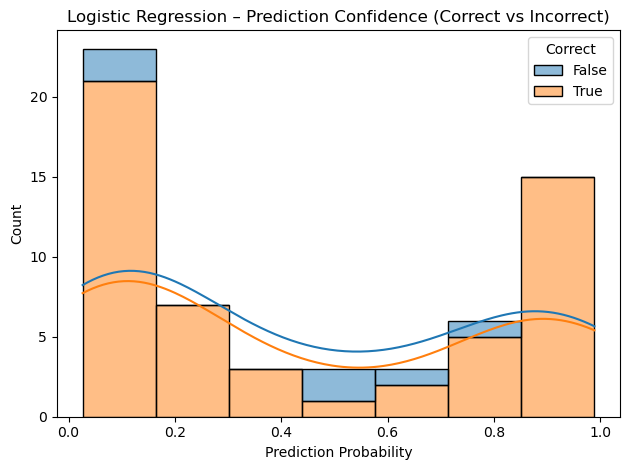

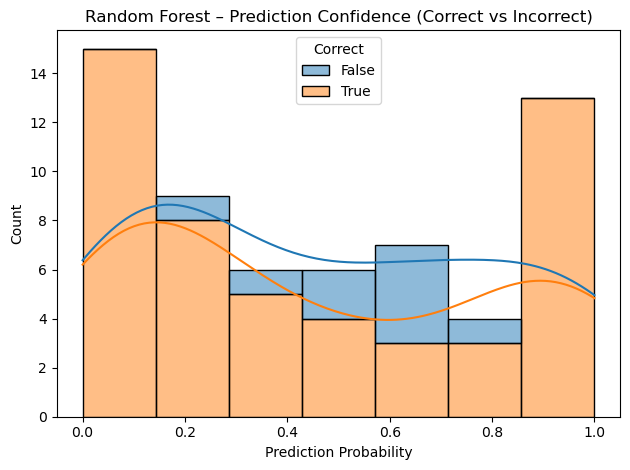

In [74]:
# Add predicted probabilities and correctness to comparison DataFrame
for model_name, y_probs in raw_probs.items():
    preds = adjusted_preds[model_name]
    df_comp = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': preds,
        'Confidence': y_probs
    })
    df_comp['Correct'] = df_comp['Actual'] == df_comp['Predicted']
    df_comp['Model'] = model_name

    # Plot distribution
    sns.histplot(data=df_comp, x='Confidence', hue='Correct', multiple='stack', kde=True)
    plt.title(f"{model_name} – Prediction Confidence (Correct vs Incorrect)")
    plt.xlabel("Prediction Probability")
    plt.tight_layout()
    plt.show()


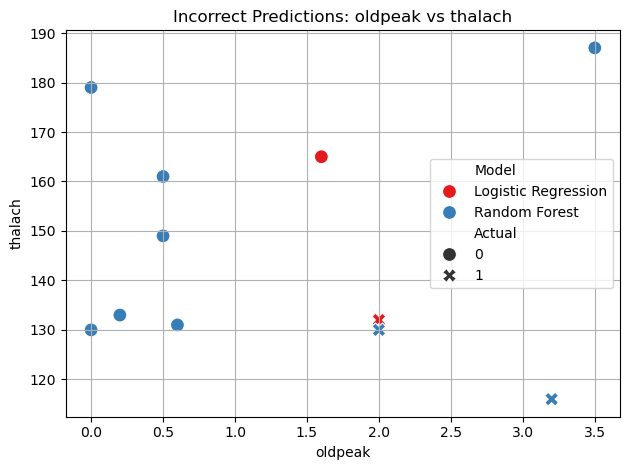

In [75]:
def plot_incorrect_distribution(df, x_feature, y_feature, hue='Model'):
    sns.scatterplot(
        data=df, x=x_feature, y=y_feature, hue=hue, style='Actual',
        palette='Set1', s=100
    )
    plt.title(f"Incorrect Predictions: {x_feature} vs {y_feature}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage
plot_incorrect_distribution(incorrect_preds_df, 'oldpeak', 'thalach')

# Appendix D - META-MODELING

In [77]:
# Meta-model to predict misclassifications (Logistic Regression)
# Define target: whether each sample was misclassified by Random Forest
rf_preds = adjusted_preds['Random Forest']
meta_target = (rf_preds != y_test.values).astype(int)  # 1 = misclassified

# Define feature matrix
X_meta = df_plot.loc[y_test.index, selected_feature_cols]

# Standardize features
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# Fit logistic regression
meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(X_meta_scaled, meta_target)

# Predictions and evaluation
meta_preds = meta_model.predict(X_meta_scaled)
print("\n--- Meta-Model Classification Report ---")
print(classification_report(meta_target, meta_preds, zero_division=0))

# Coefficients
coef_series = pd.Series(meta_model.coef_[0], index=selected_feature_cols).sort_values(ascending=False)

# Markdown-style interpretation
print("\n### Feature Importance for Misclassification Likelihood (Markdown Style)\n")
for feature, coef in coef_series.items():
    direction = "more likely" if coef > 0 else "less likely"
    print(f"- **{feature}**: Higher values are *{direction}* to be misclassified (coef = {coef:.3f})")


--- Meta-Model Classification Report ---
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        51
           1       0.00      0.00      0.00         9

    accuracy                           0.85        60
   macro avg       0.42      0.50      0.46        60
weighted avg       0.72      0.85      0.78        60


### Feature Importance for Misclassification Likelihood (Markdown Style)

- **thalach**: Higher values are *more likely* to be misclassified (coef = 0.460)
- **slope**: Higher values are *more likely* to be misclassified (coef = 0.095)
- **oldpeak**: Higher values are *more likely* to be misclassified (coef = 0.071)
- **thal**: Higher values are *more likely* to be misclassified (coef = 0.061)
- **ca**: Higher values are *more likely* to be misclassified (coef = 0.027)
- **sex**: Higher values are *less likely* to be misclassified (coef = -0.033)
- **cp**: Higher values are *less likely* to be misclassified (coef = -0.073)

### Interpretation of Meta-Model Classification Report

- **Class 0**: Correct predictions by the original model (Random Forest)
- **Class 1**: Incorrect predictions (misclassifications)

| Metric       | Explanation                                                                 |
|--------------|-----------------------------------------------------------------------------|
| **Precision**| Among predicted positives (errors), how many were actually errors          |
| **Recall**   | Among actual errors, how many were correctly predicted as errors           |
| **F1-Score** | Harmonic mean of precision and recall                                       |
| **Support**  | Number of samples in each true class                                        |

**In this case:**

- The model does not identify any actual errors (class 1), so precision and recall for that class are 0.
- Accuracy is high because most samples are correctly predicted (class 0), but that's misleading.

### Do these results reflect a true predictive signal or overfitting - testing:

- Try cross-validation: Run 3–5 fold cross-validation on the meta-model to see if it generalizes.
- Shuffle the target: Replace meta_target with a shuffled version to assess if the model is memorizing noise.

In [79]:
# Set up data and target
rf_preds = adjusted_preds['Random Forest']
meta_target = (rf_preds != y_test.values).astype(int)
X_meta = df_plot.loc[y_test.index, selected_feature_cols]

# Scale features
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# Logistic Regression with increased iterations to ensure convergence
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(meta_model, X_meta_scaled, meta_target, cv=cv, scoring='f1')

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", round(cv_scores.mean(), 3))

Cross-Validation F1 Scores: [0. 0. 0. 0. 0.]
Mean F1 Score: 0.0


**Interpretation:**  
The meta-model (Logistic Regression) appeared to perform decently on the original test set — with 85% accuracy, even though it failed to detect any actual errors (class 1).  
However, the cross-validation results reveal the truth:
- The model completely fails to generalize.
- In every fold, it scored an F1 of 0, meaning it never correctly predicted any misclassified samples.
- Despite high training accuracy, it does not learn a real pattern for predicting misclassifications.

In [81]:
# Shuffle the target
shuffled_target = shuffle(meta_target, random_state=42)

# Fit on original scaled features with shuffled labels
meta_model.fit(X_meta_scaled, shuffled_target)
shuffled_preds = meta_model.predict(X_meta_scaled)

print("\n--- Meta-Model (Shuffled Target) Classification Report ---")
print(classification_report(shuffled_target, shuffled_preds, zero_division=0))


--- Meta-Model (Shuffled Target) Classification Report ---
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        51
           1       1.00      0.11      0.20         9

    accuracy                           0.87        60
   macro avg       0.93      0.56      0.56        60
weighted avg       0.88      0.87      0.82        60



**Interpretation:**  
Class 1 (misclassifications) was randomly assigned via shuffling.

- The model is not just memorizing the noise, but it's also not generalizing any useful signal from it.
- This test confirms that the original meta-model performance was likely driven by data quirks or imbalance — not true predictive power.

In [83]:
# Meta-model to predict misclassifications (random forest classifier)
# Define target: whether each sample was misclassified by Logistic Regression
lr_preds = adjusted_preds['Logistic Regression']
meta_target = (lr_preds != y_test.values).astype(int)  # 1 = misclassified

# Feature matrix from test set
X_meta = df_plot.loc[y_test.index, selected_feature_cols]

# Fit Random Forest
meta_model_rf = RandomForestClassifier(random_state=42)
meta_model_rf.fit(X_meta, meta_target)

# Predict and evaluate
meta_preds_rf = meta_model_rf.predict(X_meta)
print("\n--- Meta-Model (RFC) Classification Report for Logistic Regression Errors ---")
print(classification_report(meta_target, meta_preds_rf, zero_division=0))

# Feature importances
importances = pd.Series(meta_model_rf.feature_importances_, index=selected_feature_cols).sort_values(ascending=False)

# Print markdown block
print("\n### Feature Importance for Misclassification Likelihood (Random Forest, Markdown Style)\n")
for feature, importance in importances.items():
    note = "important for predicting misclassifications" if importance > 0 else "not used"
    print(f"- **{feature}**: {note} (importance = {importance:.3f})")


--- Meta-Model (RFC) Classification Report for Logistic Regression Errors ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00         6

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


### Feature Importance for Misclassification Likelihood (Random Forest, Markdown Style)

- **thalach**: important for predicting misclassifications (importance = 0.314)
- **oldpeak**: important for predicting misclassifications (importance = 0.262)
- **slope**: important for predicting misclassifications (importance = 0.123)
- **ca**: important for predicting misclassifications (importance = 0.102)
- **cp**: important for predicting misclassifications (importance = 0.100)
- **thal**: important for predicting misclassifications (importance = 0.063)
- **sex**: important for predicting mis

In [84]:
# Set up data and model
rf_preds = adjusted_preds['Logistic Regression']
meta_target = (rf_preds != y_test.values).astype(int)
X_meta = df_plot.loc[y_test.index, selected_feature_cols]

# Random Forest with max_depth to prevent overfitting
meta_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(meta_model, X_meta, meta_target, cv=cv, scoring='f1')

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", round(cv_scores.mean(), 3))

Cross-Validation F1 Scores: [0. 0. 0. 0. 0.]
Mean F1 Score: 0.0


**Interpretation:**  
Despite earlier perfect performance, the Random Forest meta-model completely fails to generalize.  
It likely memorized noise in the small dataset and does not learn a true signal for misclassifications.

In [86]:
# Shuffle the target
shuffled_target = shuffle(meta_target, random_state=42)

# Fit and evaluate
meta_model.fit(X_meta, shuffled_target)
shuffled_preds = meta_model.predict(X_meta)

print("\n--- Meta-Model (Shuffled Target) Classification Report ---")
print(classification_report(shuffled_target, shuffled_preds, zero_division=0))


--- Meta-Model (Shuffled Target) Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       1.00      0.83      0.91         6

    accuracy                           0.98        60
   macro avg       0.99      0.92      0.95        60
weighted avg       0.98      0.98      0.98        60



**Interpretation:**  
Even with a shuffled target, the RFC meta-model shows strong results — suggesting it’s overfitting badly, possibly due to:

- Small number of error cases (support = 6)
- Model complexity (RFCs can memorize training data without regularization)

## Conclusion

These meta-models do not capture a reliable signal for predicting which samples are likely to be misclassified.

This could be due to:

- Too few misclassification examples (only 6–9 positive samples out of 60),
- Imbalanced target leading to bias toward the dominant class (no error),
- Or lack of true signal in the selected features for this specific task.